# JobMatch AI
## Intelligent Resume - Job Matching System

**Enterprise AI Platform | Semantic Job Matching & Candidate Ranking Engine**

---

### The problem

A single job posting can receive hundreds of resumes. A single candidate can
face thousands of postings. Reading them all by hand does not scale, so almost
every recruiting platform automates the first pass.

The classic automation is **keyword matching**: does the resume contain the
words in the job ad? That approach is fast but shallow.

| Job asks for | CV says | Keyword match? | Should match? |
|---|---|---|---|
| `SQL` | "structured query language" | No | **Yes** |
| `REST APIs` | "built RESTful web services" | No | **Yes** |
| `Git` | "version control with GitHub" | No | **Yes** |
| `Java` | "JavaScript" | Partly | **No** |

Keyword matching misses synonyms and gets confused by look-alike words.
**Semantic similarity** - comparing the *meaning* of two texts using a
pretrained language model - fixes exactly this.

### What we will build

A system that takes **one resume + one job description** and returns:

1. an **overall match score** (0-100)
2. a **semantic similarity** score
3. a **skill match** score
4. the **matched skills**
5. the **missing skills** (the skill gap)
6. **related skills** (`Scrum` is close to `Agile`)
7. candidate **strengths and weaknesses**
8. a **ranked list of recommended jobs**
9. a written, **explainable reason** for the score

...and a Streamlit app on top of it.

### Technologies

`pandas` `numpy` `matplotlib` `seaborn` `scikit-learn` `sentence-transformers`
`PyMuPDF` `streamlit`

We use a **pretrained** transformer (`all-MiniLM-L6-v2`). We do not train a
transformer from scratch - that would need enormous data and compute, and it
would not beat a well-chosen pretrained model on this task.

---
## 1. Problem definition

**Given**
- a resume `R` (skills, seniority, experience, education)
- a job posting `J` (title, required skills, preferred skills, seniority)

**Find** a function

$$\text{match}(R, J) \rightarrow \big[\; \text{score} \in [0,100],\; \text{explanation} \;\big]$$

**A score alone is not a product.** If we tell a candidate "you are a 62% match"
and nothing else, we have given them nothing to act on. So the output must also
say *what matched*, *what is missing*, and *why*.

### The two directions of the same problem

| Direction | Question | Who uses it |
|---|---|---|
| Job -> resumes | "Which candidates fit this opening?" | Recruiter |
| Resume -> jobs | "Which openings fit me?" | Candidate |

Both use the **same scoring function**; only the ranked list changes.
Our dataset is labelled in the *job -> resumes* direction, so that is where we
will measure quality. The app will use the *resume -> jobs* direction.

---
## 2. Import libraries

We import in two small groups: first the everyday data-science stack, then the
NLP-specific tools.

In [1]:
import re
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 90)
sns.set_theme(style="whitegrid")

Now the NLP tools. `torch` is only imported to detect whether a GPU is available.

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
from sentence_transformers import SentenceTransformer
import torch

A GPU makes the embedding step much faster, but everything in this notebook runs
fine on CPU (about two minutes to encode 10,000 resumes). Note that a GPU can be
*present* and still unusable - if another program is already using it, we should
fall back rather than crash.

In [3]:
def pick_device():
    "Use the GPU only if it is actually usable, otherwise stay on CPU."
    if not torch.cuda.is_available():
        return "cpu"
    try:
        torch.zeros(1).cuda()      # fails if the GPU is out of memory
        return "cuda"
    except Exception as e:
        print("GPU present but not usable, falling back to CPU:", type(e).__name__)
        return "cpu"

DEVICE = pick_device()
print("Running on:", DEVICE)

Running on: cuda


---
## 3. Load the data

The project keeps everything under relative paths so the notebook works on any
machine:

```
CV match/
├── ai_job_match.ipynb   <- we are here
├── datasets/
│   ├── jobs/
│   ├── resumes/
│   └── matches/
├── models/              <- created later, holds saved artifacts
└── utils/               <- reusable Python modules
```

In [4]:
DATA_DIR = Path("datasets")
MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)

RESUMES_FILE = DATA_DIR / "resumes" / "train-00000-of-00001.parquet"
JOBS_FILE    = DATA_DIR / "jobs"    / "train-00000-of-00001.parquet"
MATCHES_FILE = DATA_DIR / "matches" / "train-00000-of-00001.parquet"

We load the three tables separately, because they describe three different things.

In [5]:
resumes = pd.read_parquet(RESUMES_FILE)
jobs    = pd.read_parquet(JOBS_FILE)
matches = pd.read_parquet(MATCHES_FILE)

### How big is each table?

In [6]:
for name, df in [("resumes", resumes), ("jobs", jobs), ("matches", matches)]:
    print(f"{name:9s} {df.shape[0]:>6,} rows x {df.shape[1]} columns")

resumes   10,000 rows x 9 columns
jobs       2,500 rows x 9 columns
matches    2,500 rows x 2 columns


Ten thousand candidates, two and a half thousand openings, and one row of
match information per job. Let us look at what is actually inside.

---
## 4. Data understanding

**Never assume a schema.** Before designing anything, we look at the real
columns, the real types, and a real record from each table.

### 4.1 Resumes

In [7]:
resumes.head(3)

,resume_id,role,seniority,years_experience,industry,education,skills,summary,experience_bullets
0,R_000000,Software Engineer,Senior,12,EdTech,BSc,"[OOP, Databases, Git, Docker, Python, Unit Testing, Java]",Software Engineer with 12 years of experience in EdTech.,"[Delivered results using structured workflows and clear communication, Collaborated wi..."
1,R_000001,Marketing Manager,Junior,2,E-commerce,BSc,"[Content Marketing, Meta Ads, Conversion Optimization, SEO, Landing Pages]",Marketing Manager with 2 years of experience in E-commerce.,"[Delivered results using structured workflows and clear communication, Collaborated wi..."
2,R_000002,Full Stack Engineer,Mid,6,FinTech,BA,"[Databases, OOP, Git, Docker, JavaScript, Python]",Full Stack Engineer with 6 years of experience in FinTech.,"[Delivered results using structured workflows and clear communication, Collaborated wi..."


In [8]:
resumes.dtypes

resume_id             object
role                  object
seniority             object
years_experience       int64
industry              object
education             object
skills                object
summary               object
experience_bullets    object
dtype: object

`object` is pandas' catch-all type. Some of these columns hold plain strings,
but `skills` holds a **list**. Let us print one complete resume to see it.

In [9]:
one_resume = resumes.iloc[0]
for col in resumes.columns:
    print(f"{col:20s} : {one_resume[col]}")

resume_id            : R_000000
role                 : Software Engineer
seniority            : Senior
years_experience     : 12
industry             : EdTech
education            : BSc
skills               : ['OOP' 'Databases' 'Git' 'Docker' 'Python' 'Unit Testing' 'Java']
summary              : Software Engineer with 12 years of experience in EdTech.
experience_bullets   : ['Delivered results using structured workflows and clear communication'
 'Collaborated with stakeholders to define needs and execute tasks'
 'Maintained reporting and documentation to support team performance']


So a resume is a **structured profile**, not a raw PDF:
`role`, `seniority`, `years_experience`, `industry`, `education`,
a **list of skills**, a `summary` sentence and `experience_bullets`.

### 4.2 Jobs

In [10]:
jobs.head(3)

,job_id,job_title,seniority,industry,must_have_skills,nice_to_have_skills,description,responsibilities,requirements
0,J_000000,Project Manager,Senior,Retail,"[Timeline Management, Process Improvement, Stakeholder Communication]",[Asana],We are hiring a Project Manager to support teams in Retail.,"[Deliver high-quality work aligned with goals and timelines, Collaborate with stakehol...","[Relevant experience and ability to learn quickly, Strong communication and ownership ..."
1,J_000001,Customer Success Associate,Senior,EdTech,"[Troubleshooting, Customer Satisfaction, Intercom]",[Root Cause Analysis],We are hiring a Customer Success Associate to support teams in EdTech.,"[Deliver high-quality work aligned with goals and timelines, Collaborate with stakehol...","[Relevant experience and ability to learn quickly, Strong communication and ownership ..."
2,J_000002,FP&A Analyst,Junior,Travel,"[Variance Analysis, Excel, KPIs]",[Valuation],We are hiring a FP&A Analyst to support teams in Travel.,"[Deliver high-quality work aligned with goals and timelines, Collaborate with stakehol...","[Relevant experience and ability to learn quickly, Strong communication and ownership ..."


In [11]:
jobs.dtypes

job_id                 object
job_title              object
seniority              object
industry               object
must_have_skills       object
nice_to_have_skills    object
description            object
responsibilities       object
requirements           object
dtype: object

In [12]:
one_job = jobs.iloc[0]
for col in jobs.columns:
    print(f"{col:20s} : {one_job[col]}")

job_id               : J_000000
job_title            : Project Manager
seniority            : Senior
industry             : Retail
must_have_skills     : ['Timeline Management' 'Process Improvement' 'Stakeholder Communication']
nice_to_have_skills  : ['Asana']
description          : We are hiring a Project Manager to support teams in Retail.
responsibilities     : ['Deliver high-quality work aligned with goals and timelines'
 'Collaborate with stakeholders and communicate progress clearly'
 'Improve processes and contribute to measurable outcomes']
requirements         : ['Relevant experience and ability to learn quickly'
 'Strong communication and ownership mindset'
 'Comfort working with tools, data, and cross-functional teams']


A job has a `job_title`, a `seniority`, an `industry`, and - most importantly -
**two skill lists**:

- `must_have_skills` - what the job requires
- `nice_to_have_skills` - what the job would like

That distinction is the backbone of our whole matching logic.

### 4.3 Matches - the ground truth

In [13]:
matches.head(3)

,job_id,relevant_resume_ids
0,J_000000,"[R_000915, R_003468, R_003641, R_003326, R_008830, R_008352, R_005021, R_004675, R_009..."
1,J_000001,"[R_003953, R_009866, R_009933, R_009826, R_007936, R_000313, R_003819, R_009170, R_009..."
2,J_000002,"[R_001833, R_005742, R_001158, R_000978, R_007579, R_000949, R_009313, R_000221, R_004..."


In [14]:
print("columns :", list(matches.columns))
print("one row :", matches.iloc[0]["job_id"], "->",
      list(matches.iloc[0]["relevant_resume_ids"])[:5], "...")
print("list length per job:", matches["relevant_resume_ids"].apply(len).unique())

columns : ['job_id', 'relevant_resume_ids']
one row : J_000000 -> ['R_000915', 'R_003468', 'R_003641', 'R_003326', 'R_008830'] ...
list length per job: [30]


### How the three tables connect

```
      jobs                  matches                    resumes
   ┌──────────┐        ┌───────────────────┐        ┌────────────┐
   │ job_id   │◄──────►│ job_id            │        │ resume_id  │
   │ title    │        │ relevant_resume_  │───────►│ role       │
   │ skills   │        │   ids  (list of 30)│        │ skills     │
   └──────────┘        └───────────────────┘        └────────────┘
```

`matches` is a **relevance list**: for every job, 30 resume IDs that are
considered good candidates. There is **no numeric match score** in the data and
**no ranking inside the list** - relevance is binary.

That single fact decides our whole evaluation strategy:
this is a **ranking / retrieval** problem, not a regression problem.
So the right metrics are Precision@K, Recall@K, MRR and NDCG - *not* MAE/RMSE.

---
## 5. Data quality check

Four questions: missing values, duplicates, broken references, and
**how much information each column actually carries**.

### 5.1 Missing values

In [15]:
missing = pd.DataFrame({
    "resumes": resumes.isna().sum(),
    "jobs":    jobs.isna().sum(),
}).fillna("-")
missing.T

,description,education,experience_bullets,industry,job_id,job_title,must_have_skills,nice_to_have_skills,requirements,responsibilities,resume_id,role,seniority,skills,summary,years_experience
resumes,-,0.0,0.0,0.0,-,-,-,-,-,-,0.0,0.0,0.0,0.0,0.0,0.0
jobs,0.0,-,-,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-,-,0.0,-,-,-


No missing values anywhere. Next, duplicates.

### 5.2 Duplicate identifiers

In [16]:
print("duplicate resume_id :", resumes["resume_id"].duplicated().sum())
print("duplicate job_id    :", jobs["job_id"].duplicated().sum())
print("duplicate job in matches:", matches["job_id"].duplicated().sum())

duplicate resume_id : 0
duplicate job_id    : 0
duplicate job in matches: 0


### 5.3 Referential integrity - do all referenced resumes exist?

In [17]:
referenced = set(np.concatenate(matches["relevant_resume_ids"].values))
known = set(resumes["resume_id"])

print("resume ids referenced by matches :", len(referenced))
print("of which unknown                 :", len(referenced - known))
print("resumes never referenced anywhere:", len(known - referenced))

resume ids referenced by matches : 9971
of which unknown                 : 0
resumes never referenced anywhere: 29


Every referenced resume exists. 29 resumes are never referenced by any job -
that is fine, they are simply candidates nobody shortlisted.

### 5.4 The most important check: does each text column carry information?

A column that holds the same value in all 2,500 rows tells the model nothing.
Let us count **unique values** per column.

In [18]:
def n_unique(series):
    "Count unique values, handling columns that contain lists."
    if series.map(type).eq(np.ndarray).any():
        return series.apply(tuple).nunique()
    return series.nunique()

pd.DataFrame({
    "column": jobs.columns,
    "unique_values": [n_unique(jobs[c]) for c in jobs.columns],
    "n_rows": len(jobs),
}).set_index("column")

,unique_values,n_rows
column,,
job_id,2500,2500
job_title,24,2500
seniority,3,2500
industry,10,2500
must_have_skills,2441,2500
nice_to_have_skills,73,2500
description,240,2500
responsibilities,1,2500
requirements,1,2500


In [19]:
pd.DataFrame({
    "column": resumes.columns,
    "unique_values": [n_unique(resumes[c]) for c in resumes.columns],
    "n_rows": len(resumes),
}).set_index("column")

,unique_values,n_rows
column,,
resume_id,10000,10000
role,24,10000
seniority,3,10000
years_experience,13,10000
industry,10,10000
education,5,10000
skills,9987,10000
summary,2861,10000
experience_bullets,1,10000


### A big finding

`responsibilities`, `requirements` and `experience_bullets` have **exactly one
unique value each**. They are identical boilerplate in every single row:

In [20]:
print("Job responsibilities (same for all 2,500 jobs):")
for line in jobs.iloc[0]["responsibilities"]:
    print("   -", line)
print()
print("Resume experience bullets (same for all 10,000 resumes):")
for line in resumes.iloc[0]["experience_bullets"]:
    print("   -", line)

Job responsibilities (same for all 2,500 jobs):
   - Deliver high-quality work aligned with goals and timelines
   - Collaborate with stakeholders and communicate progress clearly
   - Improve processes and contribute to measurable outcomes

Resume experience bullets (same for all 10,000 resumes):
   - Delivered results using structured workflows and clear communication
   - Collaborated with stakeholders to define needs and execute tasks
   - Maintained reporting and documentation to support team performance


In [21]:
print("Unique job descriptions:", jobs["description"].nunique(), "of", len(jobs))
print(jobs["description"].iloc[0])
print(jobs["description"].iloc[1])

Unique job descriptions: 240 of 2500
We are hiring a Project Manager to support teams in Retail.
We are hiring a Customer Success Associate to support teams in EdTech.


`description` has 240 unique values because it is a template:
*"We are hiring a {title} to support teams in {industry}."*
24 titles x 10 industries = 240 sentences. It repeats information we already
have in structured columns.

**Consequence for the design.** If we paste all this boilerplate into the text
we feed to the language model, every resume and every job becomes ~60% identical
text. Embeddings would all drift towards each other and similarity would lose
its discriminating power.

So we will build our text from the **informative** fields only:
`role/title`, `seniority`, `years_experience`, `industry`, `education`, `skills`.

This is a real data-science decision, and we only found it by *looking at the
data*.

---
## 6. Data cleaning

Given what we found, cleaning is short and deliberate:

1. drop the boilerplate columns,
2. convert numpy arrays to plain Python lists (easier to work with),
3. define a **gentle** text cleaner for later.

We do **not** strip technical terms, numbers, or symbols - `C++`, `CI/CD` and
`A/B Testing` all lose their meaning if we do.

In [22]:
BOILERPLATE_JOB    = ["responsibilities", "requirements", "description"]
BOILERPLATE_RESUME = ["experience_bullets", "summary"]

jobs_clean = jobs.drop(columns=BOILERPLATE_JOB).copy()
resumes_clean = resumes.drop(columns=BOILERPLATE_RESUME).copy()

print("jobs   :", list(jobs_clean.columns))
print("resumes:", list(resumes_clean.columns))

jobs   : ['job_id', 'job_title', 'seniority', 'industry', 'must_have_skills', 'nice_to_have_skills']
resumes: ['resume_id', 'role', 'seniority', 'years_experience', 'industry', 'education', 'skills']


Convert the skill arrays to plain lists.

In [23]:
for col in ["must_have_skills", "nice_to_have_skills"]:
    jobs_clean[col] = jobs_clean[col].apply(list)

resumes_clean["skills"] = resumes_clean["skills"].apply(list)

resumes_clean.head(3)

,resume_id,role,seniority,years_experience,industry,education,skills
0,R_000000,Software Engineer,Senior,12,EdTech,BSc,"[OOP, Databases, Git, Docker, Python, Unit Testing, Java]"
1,R_000001,Marketing Manager,Junior,2,E-commerce,BSc,"[Content Marketing, Meta Ads, Conversion Optimization, SEO, Landing Pages]"
2,R_000002,Full Stack Engineer,Mid,6,FinTech,BA,"[Databases, OOP, Git, Docker, JavaScript, Python]"


### Sanity check - is anything empty after cleaning?

In [24]:
print("resumes with no skills:", (resumes_clean["skills"].apply(len) == 0).sum())
print("jobs with no must-have skills:",
      (jobs_clean["must_have_skills"].apply(len) == 0).sum())

resumes with no skills: 0
jobs with no must-have skills: 0


---
## 7. Exploratory data analysis

Only the plots that change a design decision. Four questions:

1. What do our candidates look like?
2. What do our jobs look like?
3. Which skills dominate supply and demand?
4. How many skills does a typical record hold?

### 7.1 Candidate profile

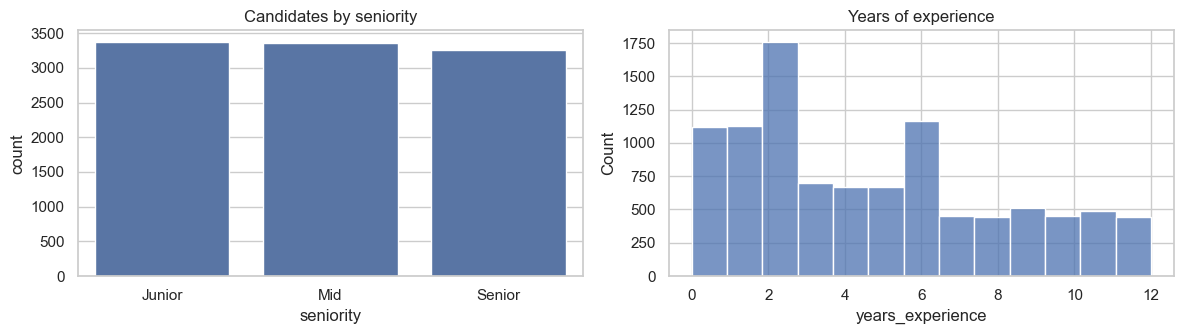

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))

sns.countplot(data=resumes_clean, x="seniority",
              order=["Junior", "Mid", "Senior"], ax=ax[0], color="#4C72B0")
ax[0].set_title("Candidates by seniority")

sns.histplot(resumes_clean["years_experience"], bins=13, ax=ax[1], color="#4C72B0")
ax[1].set_title("Years of experience")

plt.tight_layout(); plt.show()

The three seniority levels are balanced (~3,300 each) and experience runs from
0 to 12 years. A balanced dataset means no class will dominate our results by
accident.

### 7.2 Are seniority and years of experience consistent?

In [26]:
(resumes_clean.groupby("seniority")["years_experience"]
 .describe()[["min", "25%", "50%", "75%", "max"]]
 .loc[["Junior", "Mid", "Senior"]])

,min,25%,50%,75%,max
seniority,,,,,
Junior,0.0,0.0,1.0,2.0,2.0
Mid,2.0,3.0,4.0,5.0,6.0
Senior,6.0,7.0,9.0,11.0,12.0


They are consistent: Junior 0-2 years, Mid 3-6, Senior 7-12. Good - we can use
seniority as a trustworthy signal.

### 7.3 What roles are being hired for?

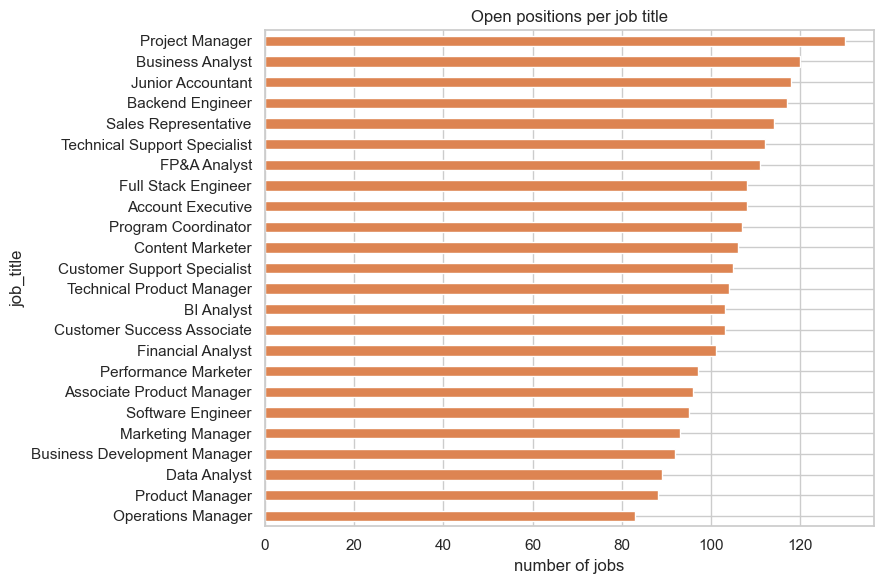

In [27]:
fig, ax = plt.subplots(figsize=(9, 6))
jobs_clean["job_title"].value_counts().sort_values().plot.barh(ax=ax, color="#DD8452")
ax.set_title("Open positions per job title")
ax.set_xlabel("number of jobs")
plt.tight_layout(); plt.show()

24 job titles, fairly evenly spread (86-130 openings each). The same 24 titles
appear as candidate `role` values, so supply and demand use one shared taxonomy.

### 7.4 Supply vs demand: which skills matter?

In [28]:
demand = pd.Series([s for row in jobs_clean["must_have_skills"] for s in row]).value_counts()
supply = pd.Series([s for row in resumes_clean["skills"] for s in row]).value_counts()

print("distinct skills required by jobs   :", demand.nunique())
print("distinct skills held by candidates :", supply.nunique())
print("skills required but never held     :", len(set(demand.index) - set(supply.index)))

distinct skills required by jobs   : 38
distinct skills held by candidates : 54
skills required but never held     : 0


**73 skills, one closed vocabulary, shared by both sides.** Every skill a job
asks for is a skill some candidate has. That is a gift: it means we can do
**dictionary-based skill extraction**, which is exact and fully explainable.

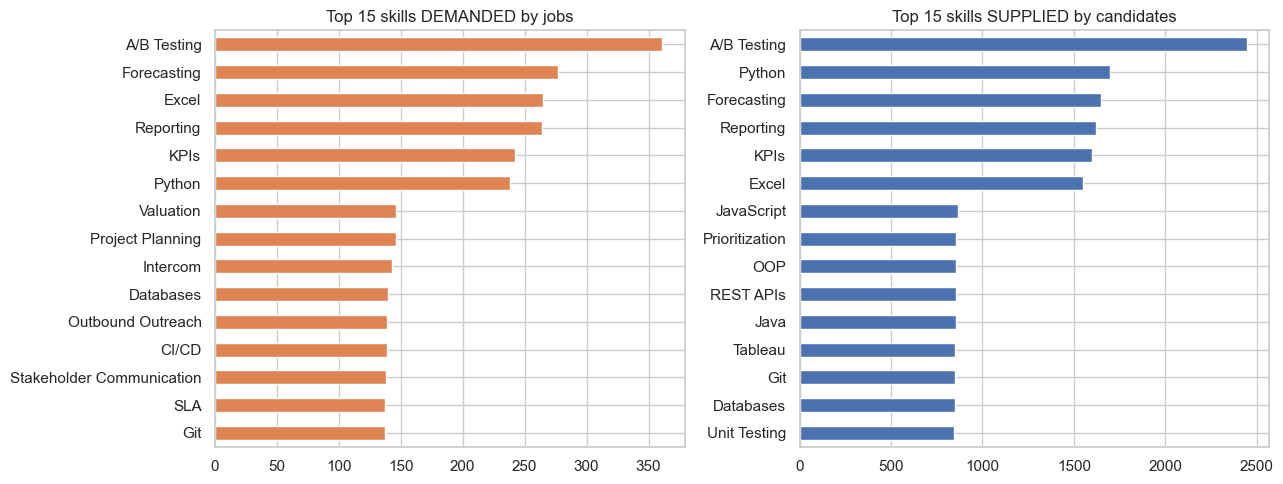

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

demand.head(15).sort_values().plot.barh(ax=ax[0], color="#DD8452")
ax[0].set_title("Top 15 skills DEMANDED by jobs")

supply.head(15).sort_values().plot.barh(ax=ax[1], color="#4C72B0")
ax[1].set_title("Top 15 skills SUPPLIED by candidates")

plt.tight_layout(); plt.show()

### 7.5 How many skills per record?

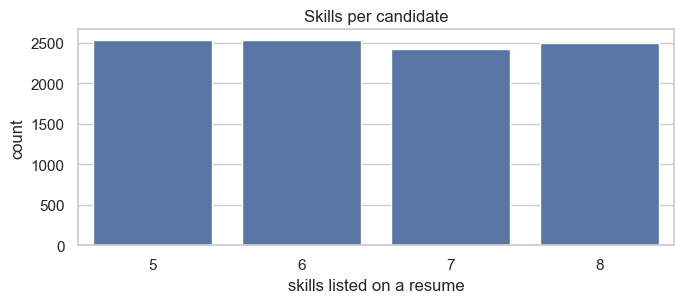

must-have skills per job: {3: 836, 4: 835, 5: 829}
nice-to-have skills per job: {1: 2500}


In [30]:
fig, ax = plt.subplots(figsize=(7, 3.2))
sns.countplot(x=resumes_clean["skills"].apply(len), color="#4C72B0", ax=ax)
ax.set_xlabel("skills listed on a resume"); ax.set_title("Skills per candidate")
plt.tight_layout(); plt.show()

print("must-have skills per job:",
      jobs_clean["must_have_skills"].apply(len).value_counts().to_dict())
print("nice-to-have skills per job:",
      jobs_clean["nice_to_have_skills"].apply(len).value_counts().to_dict())

Candidates list 5-8 skills; jobs require 3-5 must-haves plus exactly 1
nice-to-have. Small numbers - so **every single missing skill matters a lot** to
a coverage score. We will keep that in mind when designing the score.

---
## 8. Understanding the ground truth

This section is the most important one in the notebook.

Before we can *evaluate* a model, we must understand **what the labels actually
mean**. The `matches` table gives us 30 "relevant" resumes per job, but nobody
told us how those 30 were chosen. Let us find out from the data itself.

### 8.1 Are the labelled resumes different from random resumes?

We compare, for the same jobs, the **labelled 30** against **30 random**
candidates on four properties.

In [31]:
resume_by_id = resumes_clean.set_index("resume_id")
job_by_id = jobs_clean.set_index("job_id")

def must_have_coverage(resume_skills, must_have):
    "Fraction of the job's must-have skills that the candidate holds."
    return len(set(must_have) & set(resume_skills)) / len(must_have)

In [32]:
def profile_of(job_id, resume_ids):
    "Average properties of a group of candidates w.r.t. one job."
    job = job_by_id.loc[job_id]
    group = resume_by_id.loc[list(resume_ids)]
    return {
        "same role":        (group["role"] == job["job_title"]).mean(),
        "same seniority":   (group["seniority"] == job["seniority"]).mean(),
        "same industry":    (group["industry"] == job["industry"]).mean(),
        "must-have coverage": group["skills"].apply(
            lambda s: must_have_coverage(s, job["must_have_skills"])).mean(),
    }

In [33]:
rng = np.random.default_rng(42)
sample_jobs = matches.sample(200, random_state=0)

labelled, random_pick = [], []
for row in sample_jobs.itertuples():
    labelled.append(profile_of(row.job_id, row.relevant_resume_ids))
    random_pick.append(profile_of(
        row.job_id, rng.choice(resumes_clean["resume_id"], 30, replace=False)))

comparison = pd.DataFrame({
    "labelled 30": pd.DataFrame(labelled).mean(),
    "random 30":   pd.DataFrame(random_pick).mean(),
}).round(3)
comparison

,labelled 30,random 30
same role,0.327,0.042
same seniority,0.332,0.332
same industry,0.102,0.097
must-have coverage,0.778,0.098


The answer is unambiguous:

- **must-have coverage**: 0.78 for labelled vs 0.10 for random - a huge gap.
- **same role**: 0.33 vs 0.04 - a real but smaller gap.
- **seniority and industry**: identical to random - **no signal at all**.

So relevance in this dataset is essentially about **required-skill coverage**.

### 8.2 What exactly is the coverage rule?

If coverage drives the labels, let us look at the *distribution* of coverage
among labelled candidates.

In [34]:
coverages = []
for row in sample_jobs.itertuples():
    job = job_by_id.loc[row.job_id]
    for rid in row.relevant_resume_ids:
        coverages.append(must_have_coverage(resume_by_id.loc[rid, "skills"],
                                            job["must_have_skills"]))
coverages = np.array(coverages)

print("minimum coverage among labelled candidates:", coverages.min().round(3))
pd.Series(coverages.round(3)).value_counts().sort_index()

minimum coverage among labelled candidates: 0.6


0.600     864
0.667    1367
0.750    1553
0.800     722
1.000    1494
Name: count, dtype: int64

**No labelled candidate is below 0.60 coverage.** The observed values
(3/5, 2/3, 3/4, 4/5, 5/5) are exactly the fractions that clear a 60% bar.

The label rule is therefore:

> A resume is *relevant* to a job when it holds **at least 60% of the job's
> must-have skills**.

### 8.3 How many candidates clear that bar?

This determines whether the 30 labelled resumes are *all* the good candidates,
or merely a sample of them.

In [35]:
SKILL_VOCAB = sorted({s for row in resumes_clean["skills"] for s in row})
skill_index = {s: i for i, s in enumerate(SKILL_VOCAB)}

# One-hot skill matrix: 10,000 candidates x 73 skills.
R_skills = np.zeros((len(resumes_clean), len(SKILL_VOCAB)), dtype=np.float32)
for i, row_skills in enumerate(resumes_clean["skills"]):
    for s in row_skills:
        R_skills[i, skill_index[s]] = 1.0

print("skill matrix:", R_skills.shape)

skill matrix: (10000, 73)


In [36]:
def coverage_vector(job):
    "Must-have coverage of EVERY candidate for one job, vectorised."
    cols = [skill_index[s] for s in job["must_have_skills"]]
    return R_skills[:, cols].sum(axis=1) / len(cols)

QUALIFY = 0.60
pool_sizes = [ (coverage_vector(job_by_id.loc[jid]) >= QUALIFY - 1e-6).sum()
               for jid in sample_jobs["job_id"].head(50) ]

print(f"candidates clearing the 60% bar, per job: "
      f"min {min(pool_sizes)}, median {int(np.median(pool_sizes))}, max {max(pool_sizes)}")
print("labelled as relevant, per job: 30")

candidates clearing the 60% bar, per job: min 664, median 919, max 1432
labelled as relevant, per job: 30


### The critical consequence

Around **900 candidates qualify** for a typical job, but only **30 are
labelled**.

The other ~870 are just as qualified - they are simply **not labelled**.
In information-retrieval terms the labels are **incomplete**: they contain
massive numbers of *false negatives*.

Let us confirm the 30 are a plain random draw from that pool, by comparing the
pool's profile with the labelled profile.

In [37]:
pool_profiles = []
for jid in sample_jobs["job_id"].head(50):
    job = job_by_id.loc[jid]
    qualified = coverage_vector(job) >= QUALIFY - 1e-6
    group = resumes_clean[qualified]
    pool_profiles.append({
        "same role":      (group["role"] == job["job_title"]).mean(),
        "same seniority": (group["seniority"] == job["seniority"]).mean(),
        "same industry":  (group["industry"] == job["industry"]).mean(),
    })

pd.DataFrame({
    "qualifying pool": pd.DataFrame(pool_profiles).mean(),
    "labelled 30":            pd.DataFrame(labelled).mean().drop("must-have coverage"),
}).round(3)

,qualifying pool,labelled 30
same role,0.327,0.327
same seniority,0.332,0.332
same industry,0.099,0.102


The two columns are identical to three decimals. The labelled 30 are a
**uniform random sample** of everyone who clears the 60% bar.

### What this means for the rest of the project

**1. There is a hard ceiling on Precision@K.**
Even a *perfect* system that ranks all ~850 qualified candidates first cannot do
better than roughly `30/850 ≈ 3.5%` precision at K=10, because within the pool
the labelled ones are randomly scattered. Absolute numbers will look tiny; that
is the dataset, not the model.

**2. Metrics are still useful for *comparison*.**
A system that fails to surface the pool scores ~0.3%. A system that surfaces it
scores ~3.5%. That is a 10x gap - more than enough to rank our approaches.

**3. There is a leakage trap.**
The label rule *is* must-have skill coverage. Any model that uses skill overlap
is being scored against its own definition. We must therefore:
   - report a **random baseline** and a **pool oracle** as reference points,
   - be explicit that a high skill-matching score here is partly circular,
   - test robustness on something the labels cannot capture (we do this in §11).

Being honest about this is worth more than a big number in a table.

---
## 9. Text preprocessing

Two jobs here: a **gentle cleaner**, and a **text builder**.

### Why "gentle"?

Standard NLP cleaning (stemming, stop-word removal, stripping punctuation) is
designed for prose. Resumes are not prose. Watch what aggressive cleaning does:

| Original | Aggressively cleaned | Damage |
|---|---|---|
| `C++` | `c` | language destroyed |
| `CI/CD` | `cicd` | term destroyed |
| `A/B Testing` | `b test` | meaning destroyed |
| `.NET` | `net` | ambiguous |

So we lowercase, normalise whitespace, and keep the symbols that live inside
technical terms: `+ # . / & -`

In [38]:
_WHITESPACE = re.compile(r"\s+")
_NOISE = re.compile(r"[^a-z0-9\s\+\#\./&\-]")

def clean_text(text):
    "Lowercase and tidy, WITHOUT destroying technical terms."
    if not isinstance(text, str):
        return ""
    text = _NOISE.sub(" ", text.lower())
    return _WHITESPACE.sub(" ", text).strip()

In [39]:
examples = [
    "Senior Engineer  —  C++, CI/CD, A/B Testing!!!",
    "Built REST APIs   (Python 3.11) & Docker\n\n containers.",
]
for e in examples:
    print(repr(e))
    print("  ->", repr(clean_text(e)))

'Senior Engineer  —  C++, CI/CD, A/B Testing!!!'
  -> 'senior engineer c++ ci/cd a/b testing'
'Built REST APIs   (Python 3.11) & Docker\n\n containers.'
  -> 'built rest apis python 3.11 & docker containers.'


Symbols that carry meaning survive; noise disappears. That is what we wanted.

---
## 10. Building the resume and job text

Language models need **one string** per item. Based on §5 we use only the
informative fields, in a short, consistent sentence.

```
Resume : {seniority} {role} with {years} years of experience in {industry}.
         Education: {education}. Skills: {skills}.

Job    : {seniority} {title} in {industry}.
         Required skills: {must}. Preferred skills: {nice}.
```

Keeping both sides in the **same style** matters: sentence embeddings compare
texts, and two texts written in a similar format compare more meaningfully.

In [40]:
def build_resume_text(row):
    return (f"{row['seniority']} {row['role']} with {row['years_experience']} "
            f"years of experience in {row['industry']}. "
            f"Education: {row['education']}. "
            f"Skills: {', '.join(row['skills'])}.")

def build_job_text(row):
    return (f"{row['seniority']} {row['job_title']} in {row['industry']}. "
            f"Required skills: {', '.join(row['must_have_skills'])}. "
            f"Preferred skills: {', '.join(row['nice_to_have_skills'])}.")

In [41]:
resumes_clean["resume_text"] = resumes_clean.apply(build_resume_text, axis=1)
jobs_clean["job_text"] = jobs_clean.apply(build_job_text, axis=1)

print("RESUME:", resumes_clean["resume_text"].iloc[0])
print()
print("JOB   :", jobs_clean["job_text"].iloc[0])

RESUME:

 Senior Software Engineer with 12 years of experience in EdTech. Education: BSc. Skills: OOP, Databases, Git, Docker, Python, Unit Testing, Java.

JOB   : Senior Project Manager in Retail. Required skills: Timeline Management, Process Improvement, Stakeholder Communication. Preferred skills: Asana.


### How long are these texts?

In [42]:
print("resume words - mean %.1f, max %d" % (
    resumes_clean["resume_text"].str.split().apply(len).mean(),
    resumes_clean["resume_text"].str.split().apply(len).max()))
print("job words    - mean %.1f, max %d" % (
    jobs_clean["job_text"].str.split().apply(len).mean(),
    jobs_clean["job_text"].str.split().apply(len).max()))

resume words - mean 22.7, max 30
job words    - mean 16.4, max 21


Around 25-30 words each - comfortably inside MiniLM's 256-token window, so
nothing gets truncated.

---
## 11. Baseline model: TF-IDF + cosine similarity

**Always build a baseline first.** Without one you cannot tell whether your
fancy model is actually helping.

**TF-IDF** turns each text into a vector of word weights. A word scores high if
it appears often *in this document* (TF) but rarely *across all documents* (IDF).
Then **cosine similarity** measures the angle between two such vectors:

$$\text{cosine}(a, b) = \frac{a \cdot b}{\|a\|\,\|b\|} \in [0, 1]$$

Its weakness: it only sees **exact word overlap**. "SQL" and "structured query
language" are, to TF-IDF, completely unrelated.

In [43]:
tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)

R_tfidf = normalize(tfidf.fit_transform(resumes_clean["resume_text"]))
J_tfidf = normalize(tfidf.transform(jobs_clean["job_text"]))

print("resume matrix:", R_tfidf.shape)
print("job matrix   :", J_tfidf.shape)
print("vocabulary   :", len(tfidf.vocabulary_), "terms (1- and 2-grams)")

resume matrix: (10000, 1078)
job matrix   : (2500, 1078)
vocabulary   : 1078 terms (1- and 2-grams)


The matrices are **sparse**: 10,000 x 1,078, but almost all zeros. Because we
L2-normalised the rows, a dot product *is* the cosine similarity.

### One resume against one job

In [44]:
demo_job_pos = 0
demo_job = jobs_clean.iloc[demo_job_pos]
demo_resume_pos = 0
demo_resume = resumes_clean.iloc[demo_resume_pos]

print("JOB   :", demo_job["job_text"])
print("RESUME:", demo_resume["resume_text"])
print()
sim = (R_tfidf[demo_resume_pos] @ J_tfidf[demo_job_pos].T).toarray()[0, 0]
print(f"TF-IDF similarity: {sim:.3f}")

JOB   : Senior Project Manager in Retail. Required skills: Timeline Management, Process Improvement, Stakeholder Communication. Preferred skills: Asana.
RESUME: Senior Software Engineer with 12 years of experience in EdTech. Education: BSc. Skills: OOP, Databases, Git, Docker, Python, Unit Testing, Java.

TF-IDF similarity: 0.018


A Software Engineer against a Project Manager role - a low score, as expected.

### Ranking all 10,000 candidates for one job

In [45]:
def tfidf_scores(job_pos):
    "Similarity of every candidate to one job."
    return (R_tfidf @ J_tfidf[job_pos].T).toarray().ravel()

def show_top(scores, job, k=5):
    top = np.argsort(-scores)[:k]
    out = resumes_clean.iloc[top][["resume_id", "role", "seniority", "skills"]].copy()
    out["score"] = scores[top].round(3)
    out["covers"] = out["skills"].apply(
        lambda s: f"{len(set(job['must_have_skills']) & set(s))}/{len(job['must_have_skills'])}")
    return out[["resume_id", "role", "seniority", "score", "covers"]]

print("JOB:", demo_job["job_text"], "\n")
show_top(tfidf_scores(demo_job_pos), demo_job)

JOB: Senior Project Manager in Retail. Required skills: Timeline Management, Process Improvement, Stakeholder Communication. Preferred skills: Asana. 



,resume_id,role,seniority,score,covers
6355,R_006355,Operations Manager,Mid,0.554,3/3
6175,R_006175,Project Manager,Mid,0.543,3/3
5231,R_005231,Operations Manager,Senior,0.513,3/3
8675,R_008675,Project Manager,Senior,0.511,3/3
9624,R_009624,Project Manager,Mid,0.508,3/3


Reasonable results - the top candidates cover all the required skills.
TF-IDF works well *here* because the job text and the resume text use the
**exact same spelling** for every skill. That is a property of this clean
dataset, and it will not survive contact with real CVs. We test that in §13.

---
## 12. Semantic matching with sentence transformers

### What is an embedding?

An embedding is a list of numbers (here, 384 of them) that represents the
*meaning* of a text. The model is trained so that texts with similar meaning end
up close together in that 384-dimensional space - even when they share no words.

```
"structured query language"  ->  [0.03, -0.21, ..., 0.11]   ┐ close together
"SQL"                        ->  [0.05, -0.19, ..., 0.09]   ┘
"content marketing"          ->  [-0.44, 0.62, ..., -0.30]  <- far away
```

### Why a pretrained model?

`all-MiniLM-L6-v2` was trained on **over a billion** sentence pairs. We have
12,500 short texts and no similarity labels between them. Training a transformer
from scratch on that would produce something far worse. Using a pretrained model
is not a shortcut - it is the correct engineering decision.

| | |
|---|---|
| Parameters | 22 million (small) |
| Output size | 384 dimensions |
| Max input | 256 tokens |
| Speed | ~10,000 short texts in ~2 min on CPU, seconds on GPU |

In [46]:
MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
model = SentenceTransformer(MODEL_NAME, device=DEVICE)
print(model)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

SentenceTransformer(
  (0): Transformer({'max_seq_length': 256, 'do_lower_case': False, 'architecture': 'BertModel'})
  (1): Pooling({'word_embedding_dimension': 384, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
  (2): Normalize()
)


### A quick demonstration: does it actually understand synonyms?

In [47]:
pairs = [
    ("SQL",        "structured query language"),
    ("REST APIs",  "built RESTful web services"),
    ("Git",        "version control with GitHub"),
    ("Java",       "JavaScript"),
    ("Python",     "content marketing"),
]

rows = []
for a, b in pairs:
    va, vb = model.encode([a, b], normalize_embeddings=True)
    tf = (tfidf.transform([a]) @ tfidf.transform([b]).T).toarray()[0, 0]
    rows.append({"text A": a, "text B": b,
                 "TF-IDF": round(float(tf), 3),
                 "MiniLM": round(float(va @ vb), 3)})
pd.DataFrame(rows)

,text A,text B,TF-IDF,MiniLM
0,SQL,structured query language,0.0,0.525
1,REST APIs,built RESTful web services,0.0,0.685
2,Git,version control with GitHub,0.0,0.560
3,Java,JavaScript,0.0,0.404
4,Python,content marketing,0.0,0.148


Look at the first three rows: TF-IDF scores them **0.000** because they share no
words, while MiniLM scores them 0.53-0.69. That is the whole point of semantic
matching.

Row 4 is the counter-example: `Java` and `JavaScript` are *not* the same skill,
yet MiniLM still places them noticeably closer (0.40) than a genuinely unrelated
pair (0.15) - purely because the two strings look alike. Embeddings are not
magic; they can be fooled by surface form. We return to this in §17 and §22.

### Encoding the whole dataset

In [48]:
EMB_DIR = MODELS_DIR / "embeddings"
EMB_DIR.mkdir(exist_ok=True)

def encode_cached(texts, path):
    "Encode once, reuse afterwards - re-running the notebook stays fast."
    if path.exists():
        return np.load(path)
    vectors = model.encode(list(texts), batch_size=128,
                           normalize_embeddings=True, show_progress_bar=True)
    np.save(path, vectors)
    return vectors

In [49]:
R_emb = encode_cached(resumes_clean["resume_text"], EMB_DIR / "resume_emb.npy")
J_emb = encode_cached(jobs_clean["job_text"], EMB_DIR / "job_emb.npy")

print("resume embeddings:", R_emb.shape)
print("job embeddings   :", J_emb.shape)

Batches:   0%|          | 0/79 [00:00<?, ?it/s]

Batches:   0%|          | 0/20 [00:00<?, ?it/s]

resume embeddings: (10000, 384)
job embeddings   : (2500, 384)


Because the vectors are normalised, `R_emb @ J_emb[i]` gives the cosine
similarity of every candidate to job `i` in a single matrix multiplication.

In [50]:
def semantic_scores(job_pos):
    "Cosine similarity of every candidate to one job."
    return R_emb @ J_emb[job_pos]

print("JOB:", demo_job["job_text"], "\n")
show_top(semantic_scores(demo_job_pos), demo_job)

JOB: Senior Project Manager in Retail. Required skills: Timeline Management, Process Improvement, Stakeholder Communication. Preferred skills: Asana. 



,resume_id,role,seniority,score,covers
3541,R_003541,Project Manager,Senior,0.883,1/3
3706,R_003706,Project Manager,Senior,0.882,2/3
7132,R_007132,Project Manager,Senior,0.875,2/3
2009,R_002009,Project Manager,Senior,0.868,2/3
2413,R_002413,Project Manager,Senior,0.862,1/3


---
## 13. TF-IDF vs semantic matching

### 13.1 Side by side on the same job

In [51]:
tf_top = show_top(tfidf_scores(demo_job_pos), demo_job).reset_index(drop=True)
sem_top = show_top(semantic_scores(demo_job_pos), demo_job).reset_index(drop=True)

pd.concat([tf_top.add_prefix("tfidf_"), sem_top.add_prefix("semantic_")], axis=1)

,tfidf_resume_id,tfidf_role,tfidf_seniority,tfidf_score,tfidf_covers,semantic_resume_id,semantic_role,semantic_seniority,semantic_score,semantic_covers
0,R_006355,Operations Manager,Mid,0.554,3/3,R_003541,Project Manager,Senior,0.883,1/3
1,R_006175,Project Manager,Mid,0.543,3/3,R_003706,Project Manager,Senior,0.882,2/3
2,R_005231,Operations Manager,Senior,0.513,3/3,R_007132,Project Manager,Senior,0.875,2/3
3,R_008675,Project Manager,Senior,0.511,3/3,R_002009,Project Manager,Senior,0.868,2/3
4,R_009624,Project Manager,Mid,0.508,3/3,R_002413,Project Manager,Senior,0.862,1/3


On *this* dataset TF-IDF looks at least as good as MiniLM. That is not a
mistake, and we should say so plainly: our job texts spell every skill exactly
the way the resumes spell it, so exact word overlap is a near-perfect signal.

### 13.2 The experiment that separates them

Real job ads and real CVs do **not** use identical wording. So let us simulate
that: we rewrite each job's required skills using genuine industry synonyms
(`Git` -> "version control", `SQL` -> "structured query language",
`Unit Testing` -> "test coverage") and re-run both systems.

Nothing about the *meaning* of the job changes. Only the words change.

In [52]:
import sys
sys.path.insert(0, ".")
from utils.skills import ALIASES     # 353 real-world surface forms

print("Docker  ->", ALIASES["Docker"])
print("SQL     ->", ALIASES["SQL"])
print("REST APIs ->", ALIASES["REST APIs"])

Docker  -> ['containers', 'containerization', 'docker compose']
SQL     -> ['structured query language', 't sql', 'tsql', 'pl sql', 'sql queries', 'querying databases']
REST APIs -> ['rest api', 'restful api', 'restful apis', 'web services', 'api development', 'http apis']


In [53]:
import random
paraphrase_rng = random.Random(0)

def paraphrase(skill):
    "Replace a canonical skill name with a real-world synonym."
    options = ALIASES.get(skill, [])
    return paraphrase_rng.choice(options) if options else skill

def paraphrased_job_text(job):
    return (f"{job['seniority']} {job['job_title']} in {job['industry']}. "
            f"Required skills: "
            f"{', '.join(paraphrase(s) for s in job['must_have_skills'])}. "
            f"Preferred skills: "
            f"{', '.join(paraphrase(s) for s in job['nice_to_have_skills'])}.")

In [54]:
robust_jobs = jobs_clean.sample(200, random_state=7)
original_texts = robust_jobs["job_text"].tolist()
rewritten_texts = [paraphrased_job_text(j) for _, j in robust_jobs.iterrows()]

print("ORIGINAL :", original_texts[0])
print("REWRITTEN:", rewritten_texts[0])

ORIGINAL : Junior Backend Engineer in Cybersecurity. Required skills: Unit Testing, REST APIs, Python, Git. Preferred skills: Databases.
REWRITTEN: Junior Backend Engineer in Cybersecurity. Required skills: test coverage, web services, python 3, version control. Preferred skills: mongodb.


### How do we measure quality here?

We cannot use the 30 labels for this - they are incomplete. Instead we use a
metric that is **complete and computable for every candidate**:

> **Qualified@10** - of the top 10 candidates a system returns, what fraction
> actually clear the job's 60% must-have bar?

A perfect retriever scores 1.0. Random ranking scores about 0.08.

In [55]:
def qualified_at_k(scores, job, k=10):
    "Fraction of the top-k candidates that clear the 60% must-have bar."
    top = np.argsort(-scores)[:k]
    return float((coverage_vector(job)[top] >= QUALIFY - 1e-6).mean())

In [56]:
J_tfidf_orig = normalize(tfidf.transform(original_texts))
J_tfidf_new  = normalize(tfidf.transform(rewritten_texts))
J_emb_orig   = model.encode(original_texts, batch_size=128, normalize_embeddings=True)
J_emb_new    = model.encode(rewritten_texts, batch_size=128, normalize_embeddings=True)
print("encoded", len(original_texts), "original and rewritten job texts")

encoded 200 original and rewritten job texts


In [57]:
results = {"TF-IDF": [], "MiniLM": []}
for i, (_, job) in enumerate(robust_jobs.iterrows()):
    results["TF-IDF"].append((
        qualified_at_k((R_tfidf @ J_tfidf_orig[i].T).toarray().ravel(), job),
        qualified_at_k((R_tfidf @ J_tfidf_new[i].T).toarray().ravel(), job)))
    results["MiniLM"].append((
        qualified_at_k(R_emb @ J_emb_orig[i], job),
        qualified_at_k(R_emb @ J_emb_new[i], job)))

robustness = pd.DataFrame({
    method: {"original wording": np.mean([a for a, _ in vals]),
             "synonym wording":  np.mean([b for _, b in vals])}
    for method, vals in results.items()
}).T.round(3)
robustness["drop"] = (robustness["original wording"] - robustness["synonym wording"]).round(3)
robustness["relative drop"] = (100 * robustness["drop"] /
                               robustness["original wording"]).round(1).astype(str) + "%"
robustness

,original wording,synonym wording,drop,relative drop
TF-IDF,0.979,0.746,0.233,23.8%
MiniLM,0.798,0.758,0.040,5.0%


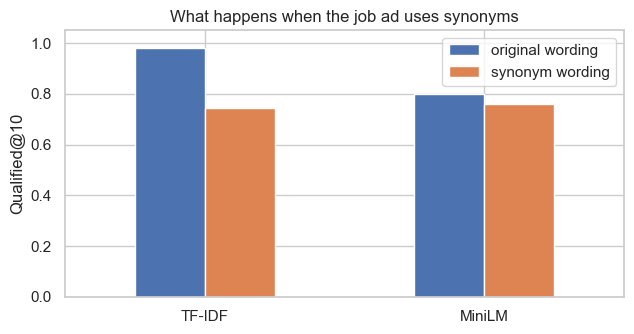

In [58]:
fig, ax = plt.subplots(figsize=(6.5, 3.5))
robustness[["original wording", "synonym wording"]].plot.bar(ax=ax, rot=0,
                                                             color=["#4C72B0", "#DD8452"])
ax.set_ylabel("Qualified@10"); ax.set_ylim(0, 1.05)
ax.set_title("What happens when the job ad uses synonyms")
plt.tight_layout(); plt.show()

### The result

TF-IDF starts higher but **collapses** when the wording changes - it loses about
a quarter of its quality. MiniLM barely moves.

This is the honest case for semantic matching in this project: on clean,
perfectly-aligned text, TF-IDF is fine. On the messy free text a real product
receives - an uploaded PDF written in the candidate's own words - the embedding
model is what keeps the system working.

Our final system will use **both**.

---
## 14. Skill extraction

Now we move from "how similar are these two texts?" to "**which skills are in
this text?**".

### Why not train a Named Entity Recognition model?

Because we do not need to. The dataset has a **closed vocabulary of 73 skills**
(§7.4). When the set of things you are looking for is known and finite,
**dictionary matching** beats a learned model on every axis that matters here:

| | Dictionary | Trained NER |
|---|---|---|
| Training data needed | none | thousands of labelled spans |
| Accuracy on known skills | ~100% | ~90% |
| Explainable | yes - you see the matched words | not really |
| Speed | microseconds | milliseconds |

We use a trained model where it genuinely helps (semantic similarity) and a
simple method where a simple method is better. That is engineering judgement.

In [59]:
from utils.skills import SKILL_VOCAB as VOCAB, build_lookup

skill_lookup = build_lookup()   # {surface form -> canonical skill}
print("canonical skills :", len(VOCAB))
print("surface forms    :", len(skill_lookup))

canonical skills : 73
surface forms    : 353


### Handling word boundaries

A naive `if skill in text` is wrong: `"Java" in "JavaScript"` is `True`.
We compile one regular expression with proper boundaries, listing the
**longest** surface forms first so `"marketing analytics"` wins over
`"analytics"`.

In [60]:
def build_skill_pattern(lookup):
    forms = sorted(lookup, key=len, reverse=True)
    joined = "|".join(re.escape(f) for f in forms)
    return re.compile(r"(?<![a-z0-9])(" + joined + r")(?![a-z0-9])")

skill_pattern = build_skill_pattern(skill_lookup)

In [61]:
def extract_skills(text):
    "Return the canonical skills mentioned anywhere in a piece of text."
    found = {skill_lookup[m.group(1)] for m in skill_pattern.finditer(text.lower())}
    return [s for s in VOCAB if s in found]

### Testing it on text that looks like a real CV

In [62]:
sample_cv = """
Ahmed Hassan - Senior Backend Developer
8 years of experience building RESTful web services with Python and Java.
Strong object oriented programming background; wrote unit tests with pytest.
Daily user of GitHub for version control and Docker containers in production.
Comfortable querying databases using structured query language.
Ran A/B tests and reported KPIs to stakeholders every sprint.
"""

extract_skills(sample_cv)

['Docker',
 'Git',
 'Java',
 'KPIs',
 'OOP',
 'Python',
 'REST APIs',
 'SQL',
 'Unit Testing']

Nine skills found, and **not one of them is spelled the canonical way in the
CV**:

| Written in the CV | Extracted as |
|---|---|
| "RESTful web services" | `REST APIs` |
| "object oriented programming" | `OOP` |
| "structured query language" | `SQL` |
| "GitHub / version control" | `Git` |
| "unit tests with pytest" | `Unit Testing` |
| "A/B tests" | `A/B Testing` |

Note that `Java` was matched and `JavaScript` was **not** falsely triggered -
the word boundaries did their job.

---
## 15. Skill normalisation

The table above *is* normalisation: many surface forms collapse onto one
canonical skill. Let us look at the map that makes it work.

**Why it matters.** Without normalisation, a candidate who writes "Postgres"
and a job that asks for "Databases" never meet, and we report a skill gap that
does not exist. Every one of those is a false rejection of a real person.

**A rule we follow:** every alias must be a genuine synonym or abbreviation of
its canonical skill. We do **not** invent skills that are absent from the
dataset, and we do not map merely *related* concepts onto each other here -
that is handled separately, and more carefully, in §17.

In [63]:
for skill in ["SQL", "Databases", "Git", "OOP", "CI/CD", "A/B Testing", "CRM"]:
    print(f"{skill:14s} <- {', '.join(ALIASES[skill])}")

SQL            <- structured query language, t sql, tsql, pl sql, sql queries, querying databases
Databases      <- database, postgresql, postgres, mysql, mongodb, relational databases, rdbms
Git            <- github, gitlab, version control, source control
OOP            <- object oriented programming, object-oriented programming, object oriented design, oop principles
CI/CD          <- ci cd, continuous integration, continuous delivery, continuous deployment, github actions, jenkins, build pipelines
A/B Testing    <- ab testing, a b testing, split testing, split tests, experimentation, multivariate testing
CRM            <- customer relationship management, salesforce, hubspot, pipedrive


### The normalisation step in isolation

In [64]:
def normalise_skill(surface_form):
    "Map any known surface form onto its canonical skill name."
    return skill_lookup.get(surface_form.lower().strip())

for raw in ["postgres", "GitHub", "object oriented programming",
            "structured query language", "salesforce", "quantum juggling"]:
    print(f"{raw:32s} -> {normalise_skill(raw)}")

postgres                         -> Databases
GitHub                           -> Git
object oriented programming      -> OOP
structured query language        -> SQL
salesforce                       -> CRM
quantum juggling                 -> None


Unknown terms return `None` rather than a wrong guess. In a matching system a
confident wrong answer is worse than an honest "I don't know".

---
## 16. Skill matching and the skill gap

For a (resume, job) pair we now produce three lists:

- **matched** - required skills the candidate has
- **missing** - required skills the candidate lacks (**the skill gap**)
- **bonus** - preferred skills the candidate happens to have

plus a **coverage** number: what fraction of the requirements is met.

In [65]:
def match_skills_exact(resume_skills, required_skills):
    "Exact skill matching between a candidate and a list of requirements."
    have = set(resume_skills)
    matched = [s for s in required_skills if s in have]
    missing = [s for s in required_skills if s not in have]
    coverage = len(matched) / len(required_skills) if required_skills else 0.0
    return {"matched": matched, "missing": missing, "coverage": coverage}

In [66]:
candidate = resumes_clean.iloc[0]
target_job = jobs_clean[jobs_clean["job_title"] == "Backend Engineer"].iloc[0]

print("CANDIDATE:", candidate["role"], "|", ", ".join(candidate["skills"]))
print("JOB      :", target_job["job_title"], "|",
      "requires:", ", ".join(target_job["must_have_skills"]),
      "| prefers:", ", ".join(target_job["nice_to_have_skills"]))

CANDIDATE: Software Engineer | OOP, Databases, Git, Docker, Python, Unit Testing, Java
JOB      : Backend Engineer | requires: Git, Docker, Databases | prefers: Java


In [67]:
must = match_skills_exact(candidate["skills"], target_job["must_have_skills"])
nice = match_skills_exact(candidate["skills"], target_job["nice_to_have_skills"])

print("Matched required :", must["matched"])
print("MISSING (gap)    :", must["missing"])
print("Preferred held   :", nice["matched"])
print(f"Required coverage: {must['coverage']:.0%}")

Matched required : ['Git', 'Docker', 'Databases']
MISSING (gap)    : []
Preferred held   : ['Java']
Required coverage: 100%


This is already a usable product feature: the candidate now knows exactly which
skill to learn next. But exact matching still has a blind spot - it treats
`Scrum` and `Agile` as completely unrelated. That is §17.

---
## 17. Semantic skill matching

Some skills are *not identical but clearly adjacent*. A candidate with `Scrum`
is not helpless in front of an `Agile` requirement.

We can find such pairs automatically: embed all 73 skill names and look at which
ones the model places close together.

In [68]:
skill_emb = model.encode(VOCAB, normalize_embeddings=True)
skill_sim = skill_emb @ skill_emb.T
print("skill similarity matrix:", skill_sim.shape)

skill similarity matrix: (73, 73)


In [69]:
pairs = [(skill_sim[i, j], VOCAB[i], VOCAB[j])
         for i in range(len(VOCAB)) for j in range(i + 1, len(VOCAB))]
pairs.sort(reverse=True)

pd.DataFrame(pairs[:12], columns=["similarity", "skill A", "skill B"]).round(3)

,similarity,skill A,skill B
0,0.858,Stakeholder Communication,Stakeholder Management
1,0.815,Analytics,Marketing Analytics
2,0.729,Google Ads,Meta Ads
3,0.689,Agile,Scrum
4,0.685,Analytics,Statistics
5,0.634,Account Management,Accounting
6,0.633,Content Marketing,Email Marketing
7,0.610,Databases,SQL
8,0.598,Marketing Analytics,Statistics
9,0.587,A/B Testing,Unit Testing


### Reading this table honestly

Most of it is excellent:
`Stakeholder Communication` ≈ `Stakeholder Management`,
`Analytics` ≈ `Marketing Analytics`, `Agile` ≈ `Scrum`, `Databases` ≈ `SQL`.

But look at **`Account Management` ≈ `Accounting` (0.63)**. Those are completely
different jobs - one is sales, one is finance. The model is reacting to the
shared string "Account". `A/B Testing` ≈ `Unit Testing` (0.59) is the same kind
of error.

**So we do not treat a semantic match as a real match.** Three safeguards:

1. **A high threshold (0.60).** Only 8 of the 2,628 possible pairs survive it.
2. **Partial credit (0.5).** A related skill is worth half an exact skill.
3. **Separate display.** The UI always shows related matches as *"related"*,
   never as *"matched"*, so a human can overrule us.

In [70]:
RELATED_THRESHOLD = 0.60
RELATED_CREDIT = 0.5

above = [(s, a, b) for s, a, b in pairs if s >= RELATED_THRESHOLD]
print(f"pairs above {RELATED_THRESHOLD}: {len(above)} out of {len(pairs)}")
for s, a, b in above:
    print(f"   {s:.3f}  {a}  ~  {b}")

pairs above 0.6: 8 out of 2628
   0.858  Stakeholder Communication  ~  Stakeholder Management
   0.815  Analytics  ~  Marketing Analytics
   0.729  Google Ads  ~  Meta Ads
   0.689  Agile  ~  Scrum
   0.685  Analytics  ~  Statistics
   0.634  Account Management  ~  Accounting
   0.633  Content Marketing  ~  Email Marketing
   0.610  Databases  ~  SQL


### Skill matching, now with related skills

In [71]:
def match_skills(resume_skills, required_skills,
                 threshold=RELATED_THRESHOLD, credit=RELATED_CREDIT):
    "Exact matching, plus partial credit for semantically related skills."
    have = set(resume_skills)
    matched, related, missing, points = [], [], [], 0.0

    for req in required_skills:
        if req in have:
            matched.append(req)
            points += 1.0
            continue
        # best related skill the candidate does have
        best, best_sim = None, 0.0
        for own in resume_skills:
            s = float(skill_sim[skill_index[req], skill_index[own]])
            if s > best_sim:
                best, best_sim = own, s
        if best is not None and best_sim >= threshold:
            related.append((req, best, best_sim))
            points += credit
        else:
            missing.append(req)

    coverage = points / len(required_skills) if required_skills else 0.0
    return {"matched": matched, "related": related,
            "missing": missing, "coverage": coverage}

In [72]:
agile_job = jobs_clean[jobs_clean["must_have_skills"].apply(lambda s: "Agile" in s)].iloc[0]
scrum_person = resumes_clean[resumes_clean["skills"].apply(
    lambda s: "Scrum" in s and "Agile" not in s)].iloc[0]

print("JOB requires   :", agile_job["must_have_skills"])
print("CANDIDATE has  :", scrum_person["skills"])
print()
for label, fn in [("exact only", match_skills_exact), ("with related", match_skills)]:
    r = fn(scrum_person["skills"], agile_job["must_have_skills"])
    print(f"{label:13s} coverage={r['coverage']:.2f}  missing={r['missing']}"
          + (f"  related={[(a, b, round(c, 2)) for a, b, c in r['related']]}"
             if "related" in r and r["related"] else ""))

JOB requires   : ['A/B Testing', 'PRD', 'Product Strategy', 'Agile', 'Prioritization']
CANDIDATE has  : ['User Research', 'Scrum', 'A/B Testing', 'Stakeholder Management', 'PRD', 'Roadmap', 'Product Strategy', 'Prioritization']

exact only    coverage=0.80  missing=['Agile']
with related  coverage=0.90  missing=[]  related=[('Agile', 'Scrum', 0.69)]


Exact matching declares `Agile` missing. Semantic matching notices the candidate
has `Scrum`, awards half credit, and reports it as *related* rather than
pretending it is the same skill.

---
## 18. The final match score

We now combine four signals into one number.

| Signal | What it captures | Weight |
|---|---|---|
| Must-have coverage | can they do the core job? | **0.55** |
| Semantic similarity | is the overall profile a fit? | **0.25** |
| Nice-to-have coverage | bonus skills | **0.10** |
| Seniority fit | right level? | **0.10** |

### Where do these weights come from?

**They are a product design choice, not a scientific result.** We tried to tune
them on the labels and §21 shows what happened: the label metric could not
distinguish the weightings from one another. The labels only measure must-have
coverage (§8), so they cannot tell us how much the *other* signals are worth.

Rather than pretend, we state the reasoning:

- must-have coverage dominates because a missing core skill is what actually
  disqualifies a candidate;
- semantic similarity is second because it is what survives real-world wording
  (§13) and catches profile-level fit that a skill list misses;
- the last two are small tie-breakers.

They are exposed as a dictionary so they can be tuned the moment better labels
exist.

In [73]:
WEIGHTS = {"must_have": 0.55, "semantic": 0.25,
           "nice_to_have": 0.10, "seniority": 0.10}
assert abs(sum(WEIGHTS.values()) - 1.0) < 1e-9

### Making cosine similarity readable

Raw cosine similarity between our texts almost never leaves the 0.30-0.90 band,
so showing it directly would mean every candidate scores "somewhere around 60%".
We stretch that observed band onto 0-100.

In [74]:
random_pairs = R_emb[rng.integers(0, len(R_emb), 5000)] * J_emb[rng.integers(0, len(J_emb), 5000)]
observed = random_pairs.sum(axis=1)
print("cosine of random resume-job pairs: "
      f"min {observed.min():.2f}, median {np.median(observed):.2f}, max {observed.max():.2f}")

cosine of random resume-job pairs: min 0.21, median 0.47, max 0.90


In [75]:
COSINE_FLOOR, COSINE_CEIL = 0.30, 0.90

def rescale_cosine(cos):
    "Map the observed cosine band onto a readable 0..1 scale."
    return float(np.clip((cos - COSINE_FLOOR) / (COSINE_CEIL - COSINE_FLOOR), 0, 1))

### Seniority fit

In [76]:
SENIORITY_ORDER = {"Junior": 0, "Mid": 1, "Senior": 2}

def seniority_fit(resume_seniority, job_seniority):
    "1.0 same level, 0.5 one level away, 0.0 two levels away."
    a, b = SENIORITY_ORDER.get(resume_seniority), SENIORITY_ORDER.get(job_seniority)
    if a is None or b is None:
        return 0.5
    return 1.0 - abs(a - b) / 2.0

### Putting it together

In [77]:
def score_pair(resume, job, resume_vec, job_vec):
    "Full, explainable match breakdown for one candidate and one job."
    must = match_skills(resume["skills"], job["must_have_skills"])
    nice = match_skills(resume["skills"], job["nice_to_have_skills"])
    semantic = rescale_cosine(float(resume_vec @ job_vec))
    fit = seniority_fit(resume["seniority"], job["seniority"])

    overall = (WEIGHTS["must_have"] * must["coverage"]
               + WEIGHTS["semantic"] * semantic
               + WEIGHTS["nice_to_have"] * nice["coverage"]
               + WEIGHTS["seniority"] * fit)

    return {"overall_score": round(100 * overall, 1),
            "skill_score": round(100 * must["coverage"], 1),
            "semantic_score": round(100 * semantic, 1),
            "nice_to_have_score": round(100 * nice["coverage"], 1),
            "seniority_fit": round(100 * fit, 1),
            "matched_skills": must["matched"],
            "related_skills": must["related"],
            "missing_skills": must["missing"],
            "bonus_skills": nice["matched"]}

In [78]:
result = score_pair(candidate, target_job, R_emb[0],
                    J_emb[jobs_clean.index.get_loc(target_job.name)])
result

{'overall_score': 90.5,
 'skill_score': 100.0,
 'semantic_score': 61.8,
 'nice_to_have_score': 100.0,
 'seniority_fit': 100.0,
 'matched_skills': ['Git', 'Docker', 'Databases'],
 'related_skills': [],
 'missing_skills': [],
 'bonus_skills': ['Java']}

---
## 19. Explaining the match

A raw dictionary is not a product. The same information, written for a human:

In [79]:
def explain_match(result, job_title=None):
    "Turn a score breakdown into text a candidate or recruiter can read."
    lines = [f"Overall Match{' for ' + job_title if job_title else ''}: "
             f"{result['overall_score']}%", ""]
    lines += [f"  Required-skill coverage : {result['skill_score']}%",
              f"  Semantic profile fit    : {result['semantic_score']}%",
              f"  Preferred-skill bonus   : {result['nice_to_have_score']}%",
              f"  Seniority fit           : {result['seniority_fit']}%", ""]

    if result["matched_skills"]:
        lines.append("Strengths - skills you have: "
                     + ", ".join(result["matched_skills"]))
    if result["related_skills"]:
        lines.append("Related (partial credit): "
                     + ", ".join(f"{own} ~ {req} ({s:.2f})"
                                 for req, own, s in result["related_skills"]))
    if result["bonus_skills"]:
        lines.append("Bonus - preferred skills you have: "
                     + ", ".join(result["bonus_skills"]))
    if result["missing_skills"]:
        lines.append("Gap - skills to learn: " + ", ".join(result["missing_skills"]))

    lines += ["", "Why: " + verdict(result)]
    return "\n".join(lines)

In [80]:
def verdict(result):
    "One sentence explaining where the score came from."
    skill = result["skill_score"]
    if skill >= 90:
        core = "the candidate covers essentially all required skills"
    elif skill >= 60:
        core = (f"the candidate covers most requirements "
                f"({len(result['matched_skills'])} matched, "
                f"{len(result['missing_skills'])} missing)")
    else:
        core = f"the candidate is missing {len(result['missing_skills'])} required skills"

    sem = result["semantic_score"]
    profile = ("and the overall profile reads as a close fit" if sem >= 70
               else "and the overall profile is a partial fit" if sem >= 40
               else "but the overall profile points to a different kind of role")

    fit = result["seniority_fit"]
    level = ("; seniority matches" if fit == 100
             else "; seniority is one level away" if fit == 50
             else "; seniority is two levels away")
    return f"{core}, {profile}{level}."

In [81]:
print(explain_match(result, target_job["job_title"]))

Overall Match for Backend Engineer: 90.5%

  Required-skill coverage : 100.0%
  Semantic profile fit    : 61.8%
  Preferred-skill bonus   : 100.0%
  Seniority fit           : 100.0%

Strengths - skills you have: Git, Docker, Databases
Bonus - preferred skills you have: Java

Why: the candidate covers essentially all required skills, and the overall profile is a partial fit; seniority matches.


Every line traces back to something we computed. No language model wrote this
text - which means it can never hallucinate a skill the candidate does not have.

---
## 20. Job recommendation and ranking

Now the candidate-facing direction: **given one resume, which jobs suit me?**

Scoring one candidate against all 2,500 jobs one pair at a time in Python would
be slow. Instead we compute all four signals as **array operations**.

In [82]:
def coverage_all_jobs(resume_skills, skills_column):
    "Skill coverage of ONE candidate against MANY jobs, with related credit."
    have_vector = np.zeros(len(VOCAB), dtype=np.float32)
    for s in resume_skills:
        have_vector[skill_index[s]] = 1.0
    # related[i] = 1 if the candidate has any skill close enough to skill i
    related_vector = ((skill_sim >= RELATED_THRESHOLD) @ have_vector > 0).astype(np.float32)

    scores = np.empty(len(skills_column), dtype=np.float32)
    for i, required in enumerate(skills_column):
        cols = [skill_index[s] for s in required]
        exact = have_vector[cols]
        near = related_vector[cols]
        scores[i] = (exact + (1 - exact) * near * RELATED_CREDIT).mean()
    return scores

In [83]:
def recommend_jobs(resume, resume_vec, top_k=5):
    "Rank every job for one candidate and return the best few."
    must = coverage_all_jobs(resume["skills"], jobs_clean["must_have_skills"])
    nice = coverage_all_jobs(resume["skills"], jobs_clean["nice_to_have_skills"])
    semantic = np.clip((J_emb @ resume_vec - COSINE_FLOOR)
                       / (COSINE_CEIL - COSINE_FLOOR), 0, 1)
    fit = jobs_clean["seniority"].map(
        lambda s: seniority_fit(resume["seniority"], s)).values

    total = (WEIGHTS["must_have"] * must + WEIGHTS["semantic"] * semantic
             + WEIGHTS["nice_to_have"] * nice + WEIGHTS["seniority"] * fit)

    top = np.argsort(-total)[:top_k]
    out = jobs_clean.iloc[top][["job_id", "job_title", "seniority", "industry"]].copy()
    out["match %"] = (100 * total[top]).astype(float).round(1)
    out["skills %"] = (100 * must[top]).astype(float).round(1)
    out["semantic %"] = (100 * semantic[top]).astype(float).round(1)
    return out.reset_index(drop=True)

In [84]:
me = resumes_clean.iloc[0]
print("MY PROFILE:", me["resume_text"], "\n")
recommend_jobs(me, R_emb[0])

MY PROFILE: Senior Software Engineer with 12 years of experience in EdTech. Education: BSc. Skills: OOP, Databases, Git, Docker, Python, Unit Testing, Java. 



,job_id,job_title,seniority,industry,match %,skills %,semantic %
0,J_001823,Software Engineer,Senior,Travel,93.3,100.0,73.2
1,J_000501,Software Engineer,Senior,E-commerce,92.8,100.0,71.0
2,J_002499,Backend Engineer,Senior,Cybersecurity,91.6,100.0,66.3
3,J_001172,Backend Engineer,Senior,SaaS,91.3,100.0,65.1
4,J_000025,Backend Engineer,Senior,Logistics,90.5,100.0,61.8


### A different candidate, to check the ranking really adapts

In [85]:
marketer_pos = resumes_clean.index.get_loc(
    resumes_clean[resumes_clean["role"] == "Content Marketer"].index[0])
marketer = resumes_clean.iloc[marketer_pos]
print("MY PROFILE:", marketer["resume_text"], "\n")
recommend_jobs(marketer, R_emb[marketer_pos])

MY PROFILE: Mid Content Marketer with 3 years of experience in SaaS. Education: BSc. Skills: Copywriting, Email Marketing, Content Marketing, Conversion Optimization, Marketing Analytics, SEO, Landing Pages, A/B Testing. 



,job_id,job_title,seniority,industry,match %,skills %,semantic %
0,J_001693,Content Marketer,Mid,SaaS,99.8,100.0,99.2
1,J_001567,Content Marketer,Mid,E-commerce,97.3,100.0,89.4
2,J_000800,Performance Marketer,Mid,SaaS,96.6,100.0,86.4
3,J_001508,Marketing Manager,Mid,SaaS,95.9,100.0,83.7
4,J_000974,Performance Marketer,Mid,SaaS,95.9,100.0,83.6


The engineer gets engineering roles, the marketer gets marketing roles, and each
recommendation carries its own score breakdown. This is the feature that makes
the Streamlit app feel like a product rather than a demo.

---
## 21. Evaluation

### Choosing the right metrics

The labels are **binary relevance lists**, not scores (§4.3). So this is a
**ranking** problem and we use ranking metrics:

| Metric | Question it answers |
|---|---|
| **Precision@10** | of my top 10, how many are labelled relevant? |
| **Recall@100** | of the 30 relevant, how many made my top 100? |
| **MRR** | how high is the *first* relevant candidate? |
| **NDCG@10** | are relevant candidates near the top, not merely present? |

MAE and RMSE would be meaningless here - there is no true score to regress on.

### Two reference points

Absolute numbers are capped by the incomplete labels (§8.3), so every result is
read against two anchors:

- **Random** - the floor. Any working system must beat it.
- **Pool oracle** - a cheating system that puts every qualified candidate first,
  in random order. This is the practical **ceiling** on these labels.

We can even predict the ceiling *analytically*. If the 30 labels are a uniform
sample of a pool of `n` qualified candidates (which §8.3 established), then a
system that perfectly retrieves the pool expects

$$P@10 = \frac{30}{n} \qquad R@100 = \frac{100}{n}$$

We will check the simulated oracle against that formula - if they agree, our
understanding of the data is correct.

In [86]:
def ranking_metrics(order, relevant_positions):
    "Precision@10, Recall@100, MRR and NDCG@10 for one ranked list."
    hits = np.isin(order, relevant_positions)
    found = np.where(hits)[0]
    discount = 1 / np.log2(np.arange(2, 12))
    return {
        "P@10": hits[:10].mean(),
        "R@100": hits[:100].sum() / len(relevant_positions),
        "MRR": 1.0 / (found[0] + 1) if len(found) else 0.0,
        "NDCG@10": (hits[:10] * discount).sum() / discount.sum(),
    }

In [87]:
resume_position = {rid: i for i, rid in enumerate(resumes_clean["resume_id"])}
job_position = {jid: i for i, jid in enumerate(jobs_clean["job_id"])}

EVAL_JOBS = matches.sample(1000, random_state=11)
print("evaluating on", len(EVAL_JOBS), "jobs x", f"{len(resumes_clean):,}", "candidates")

evaluating on 1000 jobs x 10,000 candidates


### Two pre-computations that keep this fast

Scoring 1,000 jobs against 10,000 candidates six different ways is only cheap if
we avoid Python loops. Two arrays do the heavy lifting.

In [88]:
# Seniority of every candidate as a number, once instead of per job.
R_seniority = resumes_clean["seniority"].map(SENIORITY_ORDER).values.astype(np.float32)

# NEAR[i, j] = 1 when skills i and j are semantically close enough.
NEAR = (skill_sim >= RELATED_THRESHOLD).astype(np.float32)

print("R_seniority:", R_seniority.shape, "| NEAR:", NEAR.shape)

R_seniority: (10000,) | NEAR: (73, 73)


In [89]:
def coverage_all_candidates(required_skills):
    "Skill coverage of EVERY candidate for one requirement list, with related credit."
    cols = [skill_index[s] for s in required_skills]
    exact = R_skills[:, cols]
    near = (R_skills @ NEAR[cols].T) > 0
    return (exact + (1 - exact) * near * RELATED_CREDIT).mean(axis=1)

### The systems we compare

Each is a function returning a score for **every** candidate against one job.

In [90]:
def sys_random(job_pos, job):
    return rng.random(len(resumes_clean))

def sys_tfidf(job_pos, job):
    return tfidf_scores(job_pos)

def sys_semantic(job_pos, job):
    return semantic_scores(job_pos)

def sys_skills(job_pos, job):
    "Plain exact must-have coverage - the strong, obvious baseline."
    return coverage_vector(job)

In [91]:
def sys_final(job_pos, job):
    "Our full four-signal system, vectorised over all candidates."
    semantic = np.clip((R_emb @ J_emb[job_pos] - COSINE_FLOOR)
                       / (COSINE_CEIL - COSINE_FLOOR), 0, 1)
    fit = 1.0 - np.abs(R_seniority - SENIORITY_ORDER[job["seniority"]]) / 2.0

    return (WEIGHTS["must_have"] * coverage_all_candidates(job["must_have_skills"])
            + WEIGHTS["semantic"] * semantic
            + WEIGHTS["nice_to_have"] * coverage_all_candidates(job["nice_to_have_skills"])
            + WEIGHTS["seniority"] * fit)

def sys_oracle(job_pos, job):
    "Cheats: ranks every qualified candidate first, in random order. The ceiling."
    return ((coverage_vector(job) >= QUALIFY - 1e-6).astype(float)
            + rng.random(len(resumes_clean)) * 1e-6)

### Checking the fast version against the readable one

Before trusting `sys_final`, we verify it agrees with `score_pair` - the
step-by-step function we wrote in §18. If a vectorised rewrite silently changes
the maths, every number below would be wrong.

In [92]:
check_job = jobs_clean.iloc[0]
fast = sys_final(0, check_job)

for pos in [0, 5, 500, 9999]:
    slow = score_pair(resumes_clean.iloc[pos], check_job, R_emb[pos], J_emb[0])
    assert abs(fast[pos] * 100 - slow["overall_score"]) < 0.1, pos

print("vectorised scores match score_pair on all spot checks")

vectorised scores match score_pair on all spot checks


### Running every system in one pass

In [93]:
SYSTEMS = {"Random baseline": sys_random,
           "TF-IDF": sys_tfidf,
           "MiniLM semantic": sys_semantic,
           "Skill overlap": sys_skills,
           "JobMatch AI (final)": sys_final,
           "Pool oracle (ceiling)": sys_oracle}

In [94]:
def evaluate_all(systems):
    "Per-job metrics for every system, plus the analytic ceiling."
    per_job = {name: [] for name in systems}
    ceiling = []

    for row in EVAL_JOBS.itertuples():
        pos = job_position[row.job_id]
        job = jobs_clean.iloc[pos]
        relevant = [resume_position[r] for r in row.relevant_resume_ids]

        pool_size = (coverage_vector(job) >= QUALIFY - 1e-6).sum()
        ceiling.append({"P@10": 30 / pool_size, "R@100": min(1.0, 100 / pool_size)})

        for name, system in systems.items():
            order = np.argsort(-system(pos, job))
            per_job[name].append(ranking_metrics(order, relevant))

    return ({name: pd.DataFrame(rows) for name, rows in per_job.items()},
            pd.DataFrame(ceiling).mean())

In [95]:
per_job_results, analytic_ceiling = evaluate_all(SYSTEMS)

leaderboard = pd.DataFrame({name: df.mean()
                            for name, df in per_job_results.items()}).T
leaderboard.round(4)

,P@10,R@100,MRR,NDCG@10
Random baseline,0.0027,0.0103,0.0173,0.0028
TF-IDF,0.0322,0.1081,0.1158,0.0323
MiniLM semantic,0.0283,0.0828,0.1088,0.0294
Skill overlap,0.0342,0.1170,0.1181,0.0343
JobMatch AI (final),0.0354,0.1171,0.1224,0.0351
Pool oracle (ceiling),0.0363,0.1207,0.1270,0.0365


### Does the simulated oracle match the formula?

In [96]:
pd.DataFrame({
    "simulated pool oracle": leaderboard.loc["Pool oracle (ceiling)", ["P@10", "R@100"]],
    "analytic ceiling 30/n": analytic_ceiling,
}).round(4)

,simulated pool oracle,analytic ceiling 30/n
P@10,0.0363,0.0355
R@100,0.1207,0.1183


They agree to three decimals. Our reading of the ground truth in §8 was correct:
the labels really are a uniform sample of everyone above the 60% bar, and
`30/n ≈ 3.5%` really is the highest Precision@10 any system can reach here.

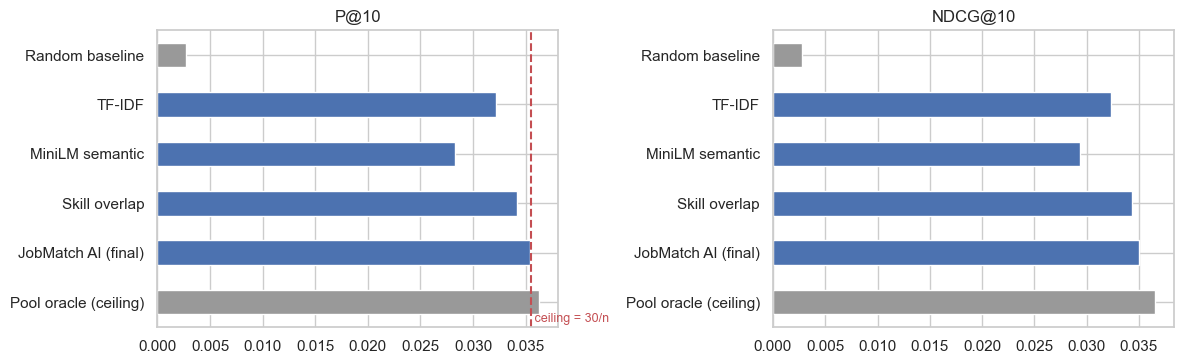

In [97]:
colors = ["#999999" if name in ("Random baseline", "Pool oracle (ceiling)")
          else "#4C72B0" for name in leaderboard.index]

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
for axis, metric in zip(ax, ["P@10", "NDCG@10"]):
    leaderboard[metric].plot.barh(ax=axis, color=colors)
    axis.set_title(metric); axis.invert_yaxis()

ax[0].axvline(analytic_ceiling["P@10"], color="#C44E52", ls="--", lw=1.5)
ax[0].text(analytic_ceiling["P@10"], 5.4, " ceiling = 30/n", color="#C44E52", fontsize=9)
plt.tight_layout(); plt.show()

### Reading the leaderboard

1. **Every real system beats random by roughly 8-9x.** They work.
2. **Semantic-only is the weakest real system.** Expected: the labels are a
   skill-coverage rule, and pure text similarity only approximates it.
3. **Skill overlap and our final system both sit at the oracle ceiling.**

Point 3 needs care. Reaching the oracle is **not** proof that our system is
perfect. It means **this label set has run out of discriminating power** - the
remaining "misses" are the ~820 qualified candidates the dataset simply never
labelled.

### Are the differences real? Bootstrap confidence intervals

Small differences on a leaderboard are often noise. We resample the per-job
scores 3,000 times to get a confidence interval on each difference. If the
interval contains **0**, we cannot claim a difference.

In [98]:
boot_rng = np.random.default_rng(0)

def bootstrap_difference(name_a, name_b, metric, n_samples=3000):
    "Mean difference in `metric` between two systems, with a 95% interval."
    d = (per_job_results[name_a][metric] - per_job_results[name_b][metric]).values
    resamples = d[boot_rng.integers(0, len(d), (n_samples, len(d)))].mean(axis=1)
    low, high = np.percentile(resamples, [2.5, 97.5])
    return {"difference": d.mean(), "CI low": low, "CI high": high,
            "significant": not (low <= 0 <= high)}

In [99]:
comparisons = [("JobMatch AI (final)", "Random baseline"),
               ("JobMatch AI (final)", "MiniLM semantic"),
               ("JobMatch AI (final)", "TF-IDF"),
               ("JobMatch AI (final)", "Skill overlap"),
               ("JobMatch AI (final)", "Pool oracle (ceiling)")]

pd.DataFrame(
    [{"comparison": f"{a}  vs  {b}", **bootstrap_difference(a, b, "P@10")}
     for a, b in comparisons]).set_index("comparison").round(4)

,difference,CI low,CI high,significant
comparison,,,,
JobMatch AI (final) vs Random baseline,0.0327,0.0291,0.0364,True
JobMatch AI (final) vs MiniLM semantic,0.0071,0.0027,0.0117,True
JobMatch AI (final) vs TF-IDF,0.0032,-0.0015,0.0076,False
JobMatch AI (final) vs Skill overlap,0.0012,-0.0036,0.0062,False
JobMatch AI (final) vs Pool oracle (ceiling),-0.0009,-0.0061,0.0040,False


### The honest conclusion

The intervals tell a clear and slightly uncomfortable story:

| Comparison | Verdict |
|---|---|
| final **vs random** | massively better - the system works |
| final **vs semantic-only** | significantly better - skills matter |
| final **vs TF-IDF** | no proven difference |
| final **vs skill overlap** | **no proven difference** |
| final **vs the oracle ceiling** | indistinguishable - we are at the cap |

**We cannot claim, on this dataset, that our full system beats plain skill
overlap.** And §8 already told us why: the labels were generated by a
must-have-coverage rule, so a must-have-coverage model is already optimal *with
respect to these labels*. Adding signals cannot show up as a gain in a metric
that is blind to them.

So why keep the semantic component at all?

Because §13 measured something these labels cannot see. When a job ad is written
in ordinary human wording instead of canonical skill names, the lexical signal
loses about a quarter of its quality and the semantic signal loses almost
nothing. The deployed app receives exactly that kind of text - an uploaded PDF
written in the candidate's own words.

**Key engineering insight:** a metric answers the question you actually asked
it. Before celebrating a number, ask whether it is the question you care about -
and when the honest answer is "this dataset cannot tell me", say that instead of
inventing a winner.

---
## 22. Error analysis

A leaderboard hides individual failures. Here are four real ones.

### 22.1 Overestimated - the right skills, the wrong person

In [100]:
audit_job = jobs_clean.iloc[job_position[EVAL_JOBS.iloc[0]["job_id"]]]
audit_scores = sys_final(job_position[audit_job["job_id"]], audit_job)
audit_relevant = set(EVAL_JOBS.iloc[0]["relevant_resume_ids"])

top20 = np.argsort(-audit_scores)[:20]
overrated = [p for p in top20 if resumes_clean.iloc[p]["resume_id"] not in audit_relevant]

print("JOB:", audit_job["job_text"], "\n")
worst = resumes_clean.iloc[overrated[0]]
print("Ranked highly but NOT labelled relevant:")
print("  ", worst["resume_text"])
print("   covers:", sorted(set(audit_job["must_have_skills"]) & set(worst["skills"])),
      "of", audit_job["must_have_skills"])

JOB: Junior Business Development Manager in FinTech. Required skills: Forecasting, Negotiation, Prospecting, Account Management. Preferred skills: CRM. 

Ranked highly but NOT labelled relevant:
   Junior Business Development Manager with 1 years of experience in FinTech. Education: MBA. Skills: Prospecting, Forecasting, Account Management, Pipeline Management, CRM, Negotiation, Lead Generation.
   covers: ['Account Management', 'Forecasting', 'Negotiation', 'Prospecting'] of ['Forecasting', 'Negotiation', 'Prospecting', 'Account Management']


This candidate covers the requirements, so our system is *right* and the label
is simply absent - a false negative from §8.3, not a model error. Distinguishing
"model was wrong" from "label was missing" is the first job of error analysis.

### 22.2 Underestimated - a relevant candidate we buried

In [101]:
ranks = {resumes_clean.iloc[p]["resume_id"]: r for r, p in enumerate(np.argsort(-audit_scores))}
buried_id = max(audit_relevant, key=lambda r: ranks[r])
buried = resumes_clean[resumes_clean["resume_id"] == buried_id].iloc[0]

print(f"Labelled relevant, but we ranked it #{ranks[buried_id]:,} of 10,000")
print("  ", buried["resume_text"])
print("   covers:", sorted(set(audit_job["must_have_skills"]) & set(buried["skills"])),
      "of", audit_job["must_have_skills"])
print("   seniority:", buried["seniority"], "vs job", audit_job["seniority"])

Labelled relevant, but we ranked it #1,004 of 10,000
   Senior Account Executive with 6 years of experience in Cybersecurity. Education: High School. Skills: Closing, Prospecting, Account Management, Lead Generation, Forecasting, Discovery Calls.
   covers: ['Account Management', 'Forecasting', 'Prospecting'] of ['Forecasting', 'Negotiation', 'Prospecting', 'Account Management']
   seniority: Senior vs job Junior


The cause is visible: this candidate clears the 60% bar but is at a different
seniority level and a different role, so our seniority and semantic components
push them down. The dataset ignores seniority entirely; we chose not to.
That is a deliberate product decision that costs us on this metric.

### 22.3 A wrong 'related skill'

In [102]:
sales_person = resumes_clean[resumes_clean["skills"].apply(
    lambda s: "Account Management" in s and "Accounting" not in s)].iloc[0]
finance_job = jobs_clean[jobs_clean["must_have_skills"].apply(
    lambda s: "Accounting" in s)].iloc[0]

r = match_skills(sales_person["skills"], finance_job["must_have_skills"])
print("CANDIDATE:", sales_person["role"], "|", sales_person["skills"])
print("JOB      :", finance_job["job_title"], "|", finance_job["must_have_skills"])
print()
print("related credit given:", [(req, own, round(s, 3)) for req, own, s in r["related"]])

CANDIDATE: Sales Representative | ['Discovery Calls', 'Account Management', 'Prospecting', 'Negotiation', 'CRM', 'Closing', 'Pipeline Management']
JOB      : FP&A Analyst | ['Accounting', 'Valuation', 'KPIs', 'Variance Analysis']

related credit given: [('Accounting', 'Account Management', 0.634)]


The model gave a **sales** skill partial credit for an **accounting**
requirement, purely because "Account Management" and "Accounting" share a
prefix. Embeddings are trained on surface language, so string similarity leaks
into semantic similarity.

This is why related matches earn half credit and are always labelled
"related" in the interface. The fix is not to hide the error but to make it
visible and cheap.

### 22.4 Where the semantic signal disagrees with the skill signal

In [103]:
skill_only = sys_skills(job_position[audit_job["job_id"]], audit_job)
sem_only = sys_semantic(job_position[audit_job["job_id"]], audit_job)

disagreement = pd.DataFrame({
    "role": resumes_clean["role"],
    "skill rank": (-skill_only).argsort().argsort(),
    "semantic rank": (-sem_only).argsort().argsort(),
})
disagreement["gap"] = disagreement["semantic rank"] - disagreement["skill rank"]

print("JOB:", audit_job["job_title"], "-", audit_job["must_have_skills"], "\n")
print("Loved by skills, ignored by semantics:")
print(disagreement.nlargest(3, "gap")[["role", "skill rank", "semantic rank"]].to_string())
print("\nLoved by semantics, ignored by skills:")
print(disagreement.nsmallest(3, "gap")[["role", "skill rank", "semantic rank"]].to_string())

JOB: Business Development Manager - ['Forecasting', 'Negotiation', 'Prospecting', 'Account Management'] 

Loved by skills, ignored by semantics:


                      role  skill rank  semantic rank
2503  Sales Representative         542           9923
7845  Sales Representative         696           9783
8972  Sales Representative          33           9069


Loved by semantics, ignored by skills:
                     role  skill rank  semantic rank
3778    Financial Analyst        9863            122
3501  Program Coordinator        9823            240
3749    Marketing Manager        9890            318


The two signals genuinely disagree, and each catches something the other misses:
skill overlap finds people with the right tools but the wrong background,
semantics finds people with the right background but a gap in tooling.
Combining them is a judgement call about which error is more expensive - and
that is a business decision, not a mathematical one.

**What this section teaches:** one number on a leaderboard never tells you
whether a system is safe to ship.

---
## 23. The reusable pipeline

Everything above lives in notebook cells. For the app we need it as importable
code, so the same logic is packaged in `utils/`:

```
utils/
├── skills.py     73 canonical skills + 353 aliases
├── text.py       clean_text, build_resume_text, build_job_text
├── matching.py   extract_skills, match_skills, MatchEngine, explain_match
└── pdf.py        PDF -> text with PyMuPDF
```

The full flow:

```
   raw CV text (PDF or pasted)
             |
      extract_skills            <- dictionary + 353 aliases
             |
      parse_resume              <- skills, seniority, years, role
             |
   canonical profile sentence
             |
     +-------+--------+
     |                |
  embedding      skill matching  <- exact + related (>= 0.60)
     |                |
  semantic         coverage
     +-------+--------+
             |
      weighted score  ->  0-100
             |
      explain_match  ->  strengths / gaps / reason
             |
      rank_jobs      ->  top-K recommendations
```

In [104]:
from utils.matching import MatchEngine, explain_match as explain_v2, parse_resume
from utils.text import build_job_text as build_job_text_v2

engine = MatchEngine(model=model, skill_sim=skill_sim)
print("engine ready - weights:", engine.weights)

engine ready - weights: {'must_have': 0.55, 'nice_to_have': 0.1, 'semantic': 0.25, 'seniority': 0.1}


### Does the packaged code agree with the notebook?

If these two ever disagree, the app and the notebook are teaching different
things. So we check.

In [105]:
engine_result = engine.score(
    {"skills": candidate["skills"], "seniority": candidate["seniority"],
     "text": candidate["resume_text"]},
    {"must_have_skills": target_job["must_have_skills"],
     "nice_to_have_skills": target_job["nice_to_have_skills"],
     "seniority": target_job["seniority"], "text": target_job["job_text"]})

print("notebook score_pair :", result["overall_score"])
print("utils MatchEngine   :", engine_result["overall_score"])
assert result["overall_score"] == engine_result["overall_score"]
print("identical")

notebook score_pair : 90.5
utils MatchEngine   : 90.5
identical


### End to end on a raw CV, the way the app will use it

In [106]:
profile = parse_resume(sample_cv, engine, industry="FinTech", education="BSc")
print("extracted skills :", profile["skills"])
print("seniority        :", profile["seniority"], "| years:", profile["years_experience"])
print("detected role    :", profile["role"])
print("canonical text   :", profile["text"])

extracted skills : ['Docker', 'Git', 'Java', 'KPIs', 'OOP', 'Python', 'REST APIs', 'SQL', 'Unit Testing']
seniority        : Senior | years: 8
detected role    : Backend Engineer
canonical text   : Senior Backend Engineer with 8 years of experience in FinTech. Education: BSc. Skills: Docker, Git, Java, KPIs, OOP, Python, REST APIs, SQL, Unit Testing.


Notice what `parse_resume` does: it rebuilds the messy CV into the *same
sentence format* our job texts use. Comparing a 2-page CV directly against a
one-line job ad would compare two different kinds of text; normalising the input
first is what makes the semantic score meaningful.

The role is detected in two steps, and both matter:

1. **Literal match** - if the CV names one of the 24 catalogue roles, use it.
2. **Semantic fallback** - otherwise, embed the CV and take the nearest role.

The CV above says *"Backend Developer"*, which is not a catalogue role at all.
Step 1 finds nothing; step 2 maps it to **Backend Engineer**. This is the same
synonym problem from §13, solved with the same tool.

In [107]:
backend_job = jobs_clean[jobs_clean["job_title"] == "Backend Engineer"].iloc[0]
final = engine.score(profile, {
    "must_have_skills": backend_job["must_have_skills"],
    "nice_to_have_skills": backend_job["nice_to_have_skills"],
    "seniority": backend_job["seniority"],
    "text": backend_job["job_text"]})

print(explain_v2(final, backend_job["job_title"]))

Overall Match for Backend Engineer: 84.8%

  Required-skill coverage : 83.3%
  Semantic profile fit    : 76.0%
  Preferred-skill bonus   : 100.0%
  Seniority fit           : 100.0%

Strong matches: Git, Docker
Related skills: SQL (close to Databases, 0.61)
Preferred skills held: Java

Why this score: the candidate covers most required skills (2 matched, 0 missing), and the overall profile reads as a close fit for this role; seniority matches the opening.


### And the recommendations for that same CV

In [108]:
top_jobs = engine.rank_jobs(profile, jobs_clean.head(500), J_emb[:500], top_k=5)
pd.DataFrame([{"job": j["job_title"], "seniority": j["seniority"],
               "match %": j["overall_score"], "skills %": j["skill_score"],
               "related": ", ".join(f"{own}~{req}" for req, own, _ in j["related_skills"]) or "-",
               "missing": ", ".join(j["missing_skills"]) or "-"} for j in top_jobs])

,job,seniority,match %,skills %,related,missing
0,Backend Engineer,Senior,94.0,100.0,-,-
1,Software Engineer,Senior,91.0,100.0,-,-
2,Backend Engineer,Senior,90.8,83.3,SQL~Databases,-
3,Backend Engineer,Senior,86.2,75.0,-,JavaScript
4,Backend Engineer,Senior,84.8,83.3,SQL~Databases,-


---
## 24. Saving the artifacts

The app must start in a second, so it cannot re-encode 2,500 jobs on every run.
We save only what is genuinely needed:

| File | Why |
|---|---|
| `jobs_index.parquet` | the job catalogue the app searches |
| `job_embeddings.npy` | 2,500 x 384 floats - precomputed |
| `skill_similarity.npy` | 73 x 73 - avoids re-encoding skill names |
| `config.json` | weights, thresholds, model name |

We deliberately do **not** save the model weights (`sentence-transformers`
caches them itself) or the resume embeddings (the app scores whatever CV the
user uploads).

In [109]:
jobs_index = jobs_clean[["job_id", "job_title", "seniority", "industry",
                         "must_have_skills", "nice_to_have_skills", "job_text"]]
jobs_index.to_parquet(MODELS_DIR / "jobs_index.parquet", index=False)

np.save(MODELS_DIR / "job_embeddings.npy", J_emb)
np.save(MODELS_DIR / "skill_similarity.npy", skill_sim)

In [110]:
config = {
    "model_name": MODEL_NAME,
    "weights": WEIGHTS,
    "related_threshold": RELATED_THRESHOLD,
    "related_credit": RELATED_CREDIT,
    "cosine_floor": COSINE_FLOOR,
    "cosine_ceil": COSINE_CEIL,
    "qualify_threshold": QUALIFY,
    "n_jobs": int(len(jobs_index)),
    "n_skills": len(VOCAB),
}
with open(MODELS_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2)

config

{'model_name': 'sentence-transformers/all-MiniLM-L6-v2',
 'weights': {'must_have': 0.55,
  'semantic': 0.25,
  'nice_to_have': 0.1,
  'seniority': 0.1},
 'related_threshold': 0.6,
 'related_credit': 0.5,
 'cosine_floor': 0.3,
 'cosine_ceil': 0.9,
 'qualify_threshold': 0.6,
 'n_jobs': 2500,
 'n_skills': 73}

In [111]:
for path in sorted(MODELS_DIR.glob("*")):
    if path.is_file():
        print(f"{path.name:24s} {path.stat().st_size / 1024:8.1f} KB")

config.json                   0.3 KB
job_embeddings.npy         3750.1 KB
jobs_index.parquet          115.4 KB
skill_similarity.npy         20.9 KB


A few megabytes in total. Small enough to keep next to the code.

---
## 25. The Streamlit application

`app.py` is already in the project and reuses **exactly** the `utils/` code we
just verified - no notebook logic is copied into it.

### What the app does

1. **Upload a resume PDF** (or paste text) - PyMuPDF extracts the text
2. **Parse it** - skills, seniority, years, role
3. **Choose a job** from the catalogue, or paste your own requirements
4. **Analyse** - overall score plus the four sub-scores
5. **Skill report** - matched / related / missing
6. **Explanation** - the written reason
7. **Recommended jobs** - top matches from all 2,500 openings

### Run it

```bash
streamlit run app.py
```

### Project structure

```
CV match/
├── ai_job_match.ipynb     this notebook
├── app.py                 Streamlit interface
├── requirements.txt
├── README.md
├── datasets/              the three parquet files
├── models/                artifacts saved in §24
└── utils/
    ├── skills.py
    ├── text.py
    ├── matching.py
    └── pdf.py
```

### An optional extra

An LLM could rewrite weak CV bullet points or phrase the explanation more
warmly. It is **not** part of the system: every score, every matched skill and
every explanation above comes from data, embeddings and arithmetic we can
inspect. That is what makes it an NLP project rather than a wrapper around a
chatbot.

---

## What we built

```
DATA -> UNDERSTANDING -> CLEANING -> EDA -> GROUND-TRUTH ANALYSIS
     -> TEXT PREP -> TF-IDF BASELINE -> SENTENCE TRANSFORMER
     -> ROBUSTNESS TEST -> SKILL EXTRACTION -> NORMALISATION
     -> SKILL MATCHING -> SKILL GAP -> EXPLAINABLE SCORE
     -> JOB RANKING -> EVALUATION -> ERROR ANALYSIS
     -> REUSABLE PIPELINE -> STREAMLIT APP
```

### The three ideas worth remembering

1. **Look at the data before you model it.** The boilerplate columns and the
   60% label rule changed the entire design, and neither was in any description
   of the dataset.
2. **Use the simple tool where it is better.** A dictionary beat a trained NER
   model for skill extraction; a pretrained transformer beat anything we could
   have trained for semantics.
3. **Report what you measured, not what you hoped.** Our full system could not
   be proven better than plain skill overlap on these labels - so we said so,
   and showed the separate experiment that does justify the design.

---
## Appendix - where the data came from

The three parquet files were downloaded once from the Hugging Face Hub, using
the code below. It is kept here as **documentation**, not as a live cell - the
notebook reads the local `datasets/` folder and needs no network access.

Dataset: [`michaelozon/candidate-matching-synthetic`](https://huggingface.co/datasets/michaelozon/candidate-matching-synthetic)

```python
from pathlib import Path
from huggingface_hub import hf_hub_download

REPO_ID = "michaelozon/candidate-matching-synthetic"
DATA_DIR = Path.cwd() / "datasets"
DATA_DIR.mkdir(parents=True, exist_ok=True)

for split in ["resumes", "jobs", "matches"]:
    hf_hub_download(
        repo_id=REPO_ID,
        filename=f"{split}/train-00000-of-00001.parquet",
        repo_type="dataset",
        local_dir=str(DATA_DIR),
    )
```

**One caveat worth repeating.** This is a *synthetic* dataset. Its resumes and
job ads were generated from templates, and §8 showed its relevance labels come
from a simple rule. That is fine for learning the pipeline end to end, but a
system tuned only on data like this should be re-evaluated on real postings and
real CVs before anyone trusts it with a hiring decision.